# ATAC analysis in CD4 T cells in TEA-Seq dataset

- related to Fig. 6 F, H, I and Fig S9 C, E


# Setup


In [ ]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library(Seurat)
quiet_library(tidyverse)
quiet_library(H5weaver)
quiet_library(dplyr)
quiet_library(viridis)
quiet_library(harmony)
quiet_library(Nebulosa)
quiet_library(future)
quiet_library(future.apply)
quiet_library("ArchR")
quiet_library("rstatix")
quiet_library("chromVAR")



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [ ]:
# Load scMACS and accompanying libraries
quiet_library(MOCHA)
quiet_library(data.table)
quiet_library(GenomicRanges)
quiet_library(plyranges)


In [ ]:
# Define your annotation package for TxDb object(s)
# and genome-wide annotation
# Here our samples are human using hg38 as a reference.
# For more info: https://bioconductor.org/packages/3.15/data/annotation/
library(TxDb.Hsapiens.UCSC.hg38.refGene)
library(BSgenome.Hsapiens.UCSC.hg38)
library(org.Hs.eg.db)
TxDb <- TxDb.Hsapiens.UCSC.hg38.refGene
Org <- org.Hs.eg.db


Loading required package: GenomicFeatures

Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:plyranges’:

    select


The following object is masked from ‘package:rstatix’:

    select


The following object is masked from ‘package:dplyr’:

    select


Loading required package: BSgenome

Loading required package: Biostrings

Loading required package: XVector


Attaching package: ‘XVector’


The following object is masked from ‘package:plyr’:

    compact


The following object is masked from ‘package:purrr’:

    compact



Attaching package: ‘Biostrings’


The following object is masked from ‘package:grid’:

    pattern


The following object is masked from ‘package:base’:

    strsplit


Loading required package: BiocIO

Loading required package: rtracklayer


Attaching package: ‘rtracklayer’


The following object is masked from ‘package:BiocIO’:

    FileForFormat






In [ ]:
# Check number of cores
future::availableCores()
# Set up parallel processing to run when using 'future' functions
future::plan(strategy = "multicore", workers = future::availableCores() - 3)
options(future.globals.maxSize = 1000 * 1024^5)
# to turn off parallel processing run line below
# future::plan(strategy = "sequential")


system 
    16

In [ ]:
# define working path
data_path <- "/home/jupyter/data/preRA_teaseq/EXP-00243"
meta_path <- "/home/jupyter/data/preRA_teaseq/meta_data"
output_path <- "/home/jupyter/data/preRA_teaseq/output_results/cd4_t/atac"
fig_path <- "/home/jupyter/data/preRA_teaseq/EXP-00243/cd4t_cells/Plots"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "PreRA_teaseq_cd4_t_atac"


In [ ]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#5AAA46", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [ ]:
source("/home/jupyter/github/Teaseq-analysis/scRNA_teaseq_ananlysis_helper_functions.r")


In [ ]:
# pathway analysis with enrichR
quiet_library(enrichR)
setEnrichrSite("Enrichr")
dbs <- listEnrichrDbs()
# %% codecell|


Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



## Load data


In [ ]:
# load the seurat object
ra_tea_cd4 <- readRDS(file.path(data_path, "PreRA_teaseq_seurat_cd4_t_filtered_cells_rmBR2024.rds"))


In [ ]:
# set ArchR parameters
addArchRThreads(threads = 55)
addArchRGenome("hg38")
set.seed(1221)
options(repr.plot.width = 20, repr.plot.height = 15)


Input threads is equal to or greater than ncores minus 1 (15)
Setting cores to ncores minus 2. Set force = TRUE to set above this number!

Setting default number of Parallel threads to 14.

Setting default genome to Hg38.



In [ ]:
# load ATAC
# load the ArchR project for CD4 t cells
cd4t_atac <- loadArchRProject(path = "/home/jupyter/data/preRA_teaseq/EXP-00243/cd4t_cells")


Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [ ]:
cd4t_atac



           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /home/jupyter/data/preRA_teaseq/EXP-00243/cd4t_cells 
samples(13): EXP-00243-P1_PB00067-03 EXP-00243-P1_PB00073-03 ...
  EXP-00243-P1_PB00501-03 EXP-00243-P1_PB00212-03
sampleColData names(1): ArrowFiles
cellColData names(51): barcodes Sample ... Clusters_0.8 CD4TnaC2toC1
numberOfCells(1): 44806
medianTSS(1): 26.517
medianFrags(1): 5364

In [ ]:
getAvailableMatrices(cd4t_atac)


[1] "GeneExpressionMatrix" "GeneScoreMatrix"      "MochaPeakMatrix"     
[4] "MotifMatrix"          "PeakMatrix"           "TileMatrix"          
[7] "TransferMatrix"       "TransferPeakMatrix"

In [ ]:
cd4t_atac <- addImputeWeights(cd4t_atac)


In [ ]:
table(ra_tea_cd4@meta.data$barcodes %in% cd4t_atac$barcodes)
table(cd4t_atac$barcodes %in% ra_tea_cd4@meta.data$barcodes)


In [ ]:
# subset the archr project to match the seurat object (remove BR2024)
idxSample <- BiocGenerics::which(cd4t_atac$barcodes %in% ra_tea_cd4@meta.data$barcodes)
cellsSample <- cd4t_atac$cellNames[idxSample]
cd4t_atac <- cd4t_atac[cellsSample, ]


In [ ]:
table(ra_tea_cd4@meta.data$barcodes %in% cd4t_atac$barcodes)
table(cd4t_atac$barcodes %in% ra_tea_cd4@meta.data$barcodes)


In [ ]:
# run LSI
cd4t_atac <- addIterativeLSI(
  ArchRProj = cd4t_atac,
  useMatrix = "TileMatrix",
  name = "IterativeLSI",
  iterations = 2,
  varFeatures = 75000,
  sampleCellsPre = 10000,
  projectCellsPre = FALSE,
  sampleCellsFinal = 100000,
  force = TRUE
)


In [ ]:
# run UMAP
cd4t_atac <- addUMAP(
    ArchRProj = cd4t_atac,
    reducedDims = "IterativeLSI", force = TRUE
)


In [ ]:
# run clustering
addArchRThreads(58)
cd4t_atac <- addClusters(
  input = cd4t_atac,
  reducedDims = "IterativeLSI",
  method = "Seurat",
  name = "Clusters_0.8",
  #  sampleCells=500000,
  resolution = 0.8,
  force = TRUE
)


In [ ]:
saveArchRProject(cd4t_atac)


In [ ]:
cd4t_atac <- addImputeWeights(cd4t_atac)


In [ ]:
ra_tea_cd4@meta.data %>% filter(atac_cell_id %in% cd4t_atac$atac_cell_id)


In [ ]:
p1 <- plotEmbedding(cd4t_atac,
    embedding = "UMAP",
    colorBy = "cellColData", name = c("clean_l2_cell_types", "Clusters_0.5", "cohort")
)
p1


### get marker to seperate cd4 cell types


In [ ]:
cd4t_atac$atac_anno <- case_when(
    cd4t_atac$Clusters_0.5 %in% c("C3", "C6", "C7", "C8", "C9") ~ "CD4_naive",
    cd4t_atac$Clusters_0.5 %in% c("C4") ~ "treg",
    cd4t_atac$Clusters_0.5 %in% c("C1") ~ "CD4_CTL",
    cd4t_atac$Clusters_0.5 %in% c("C2", "C5") ~ "CD4_memory"
)


### plot Fig6E & 6H


In [ ]:
cd4t_atac$Clusters_0_8 <- str_replace(cd4t_atac$Clusters_0.8, "C", "T")


In [ ]:
ArchRPalettes$stallion


1         2         3         4         5         6         7         8 
"#D51F26" "#272E6A" "#208A42" "#89288F" "#F47D2B" "#FEE500" "#8A9FD1" "#C06CAB" 
       19        10        11        12        13        14        15        16 
"#E6C2DC" "#90D5E4" "#89C75F" "#F37B7D" "#9983BD" "#D24B27" "#3BBCA8" "#6E4B9E" 
       17        18         9        20 
"#0C727C" "#7E1416" "#D8A767" "#3D3D3D"

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-5cf6c16577b-Date-2024-08-15_Time-17-38-41.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-5cf6c16577b-Date-2024-08-15_Time-17-38-41.log

Plotting Ggplot!



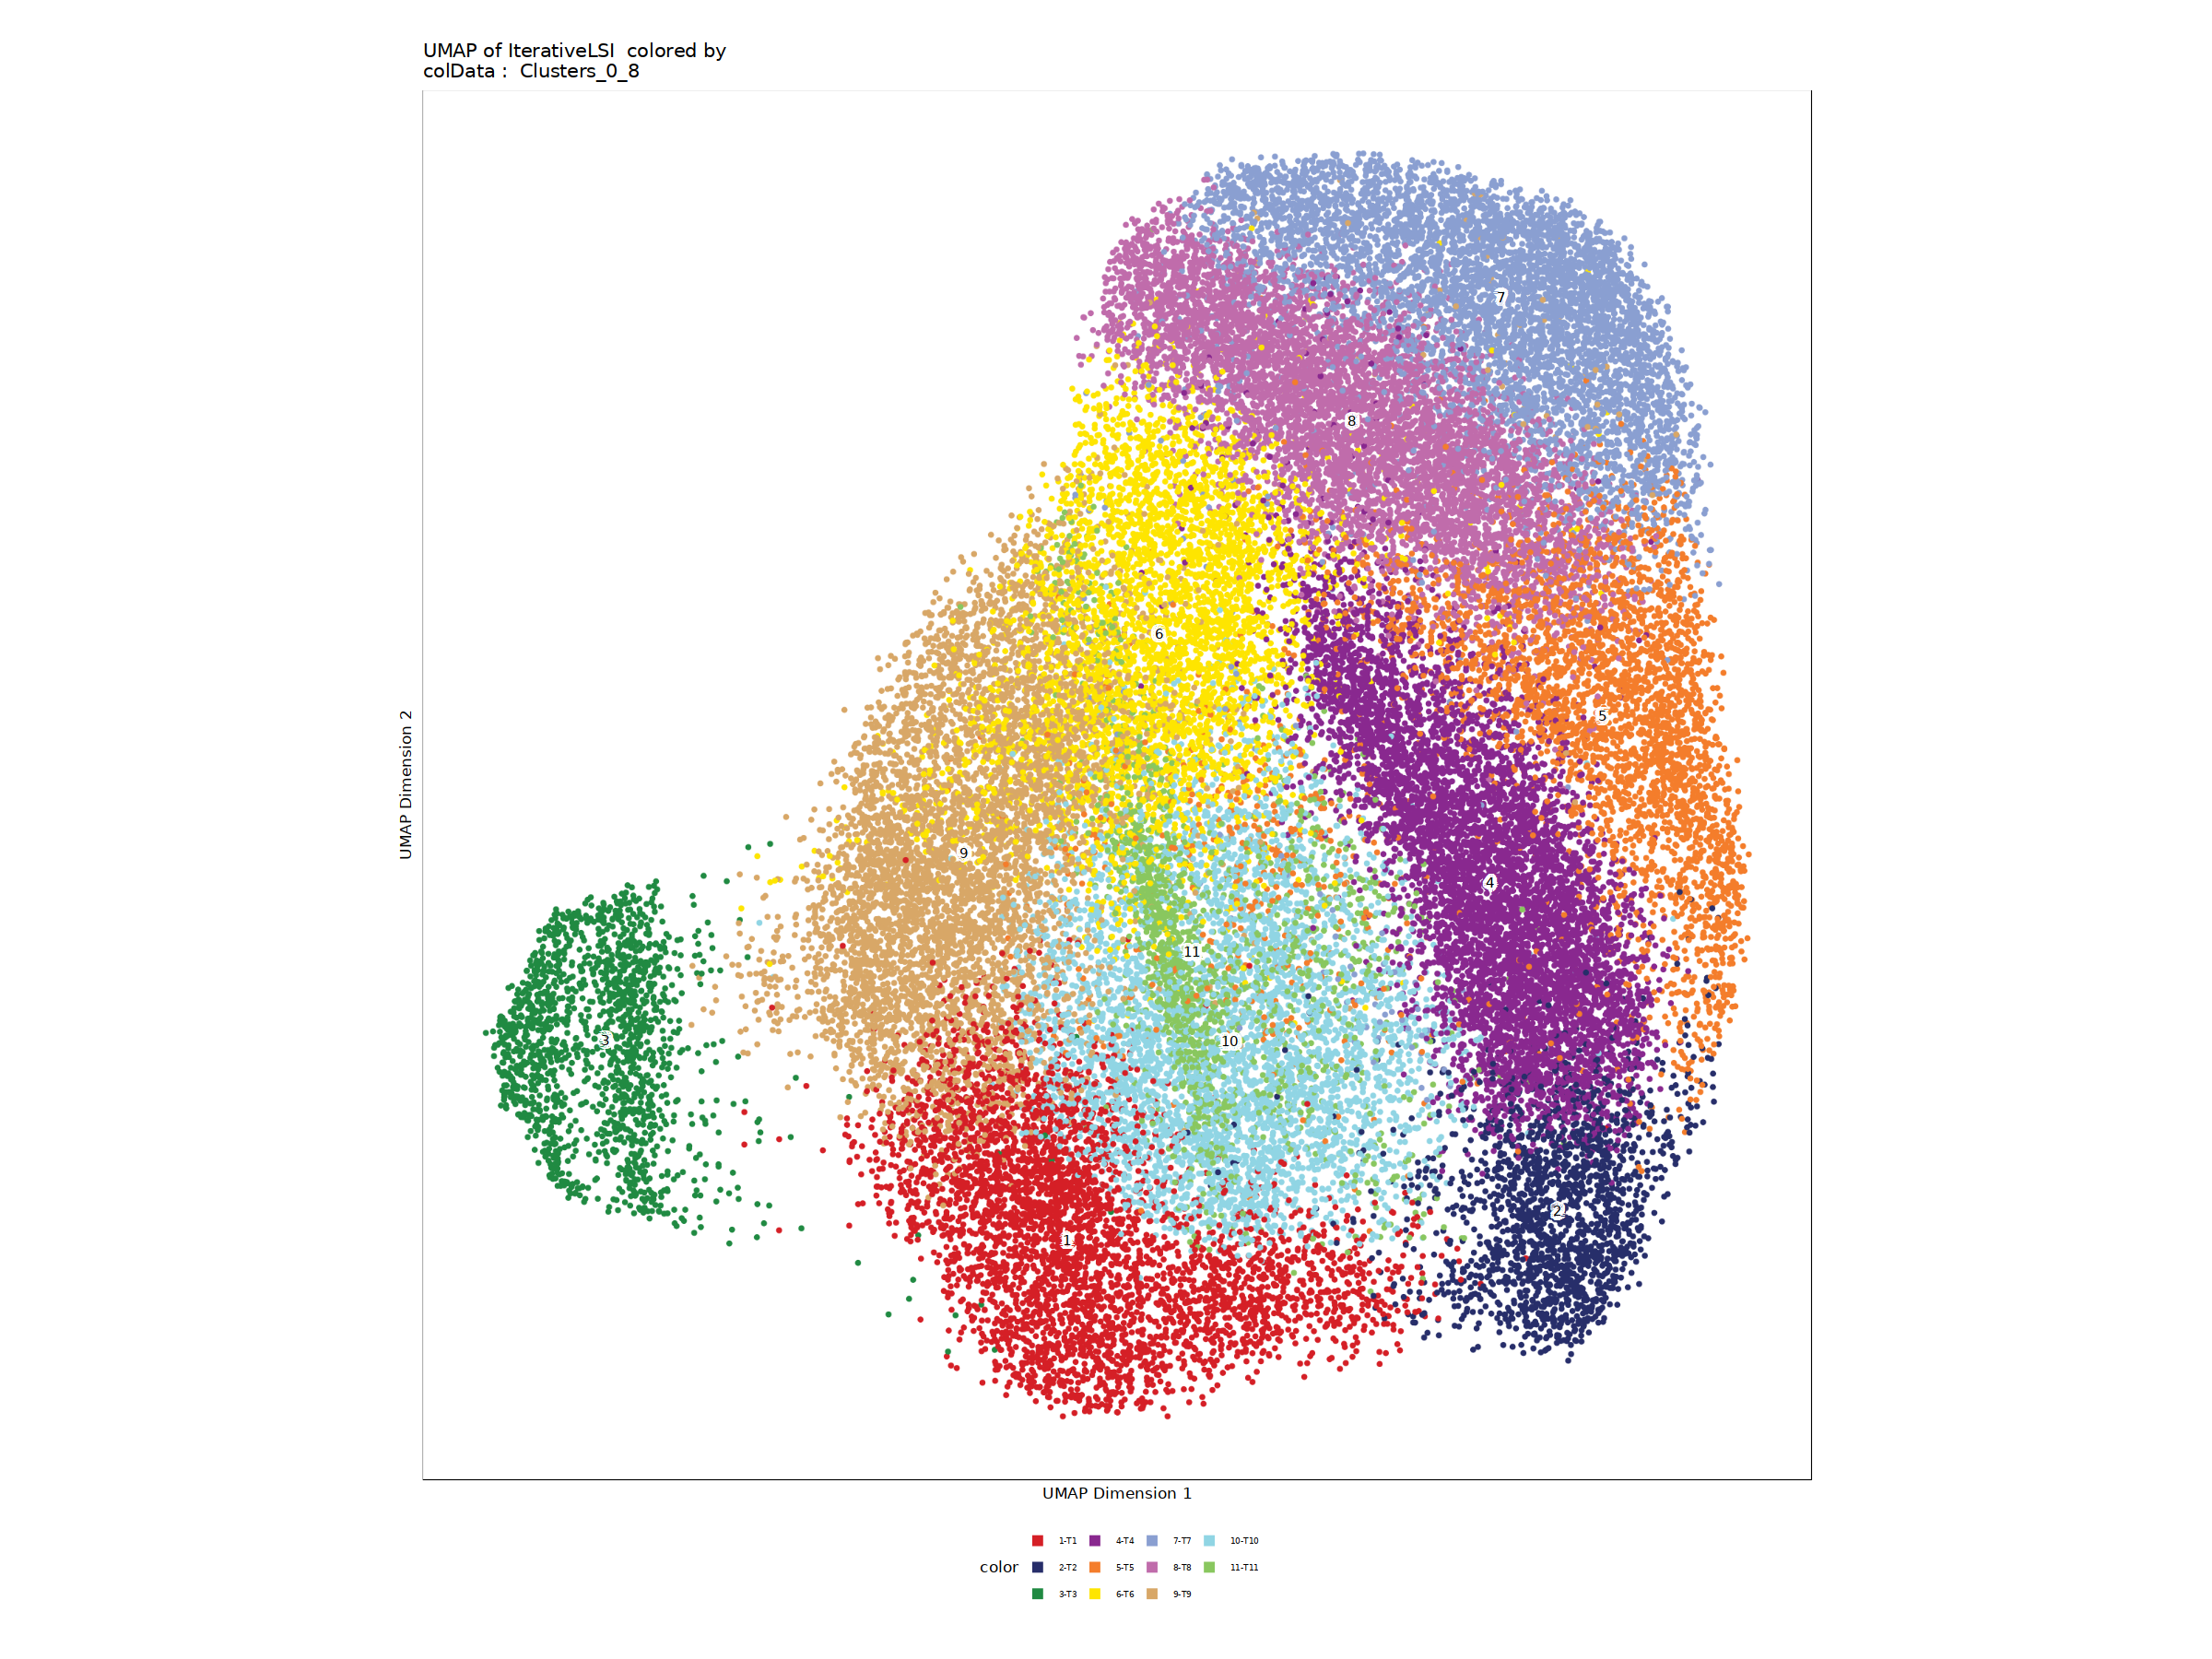

In [ ]:
p1 <- plotEmbedding(cd4t_atac,
        embedding = "UMAP", keepAxis = FALSE,
        colorBy = "cellColData",
        name = c("Clusters_0_8")
)
p1
plotPDF(p1,
        name = paste0(proj_name, "_atac_umap_Clusters_0.8.pdf"),
        ArchRProj = cd4t_atac,
        addDOC = FALSE, width = 4, height = 4
)


Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17902fac0e76-Date-2024-08-14_Time-18-32-52.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2024-08-14 18:32:52 : 



Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17902fac0e76-Date-2024-08-14_Time-18-32-52.log

Plotting Ggplot!



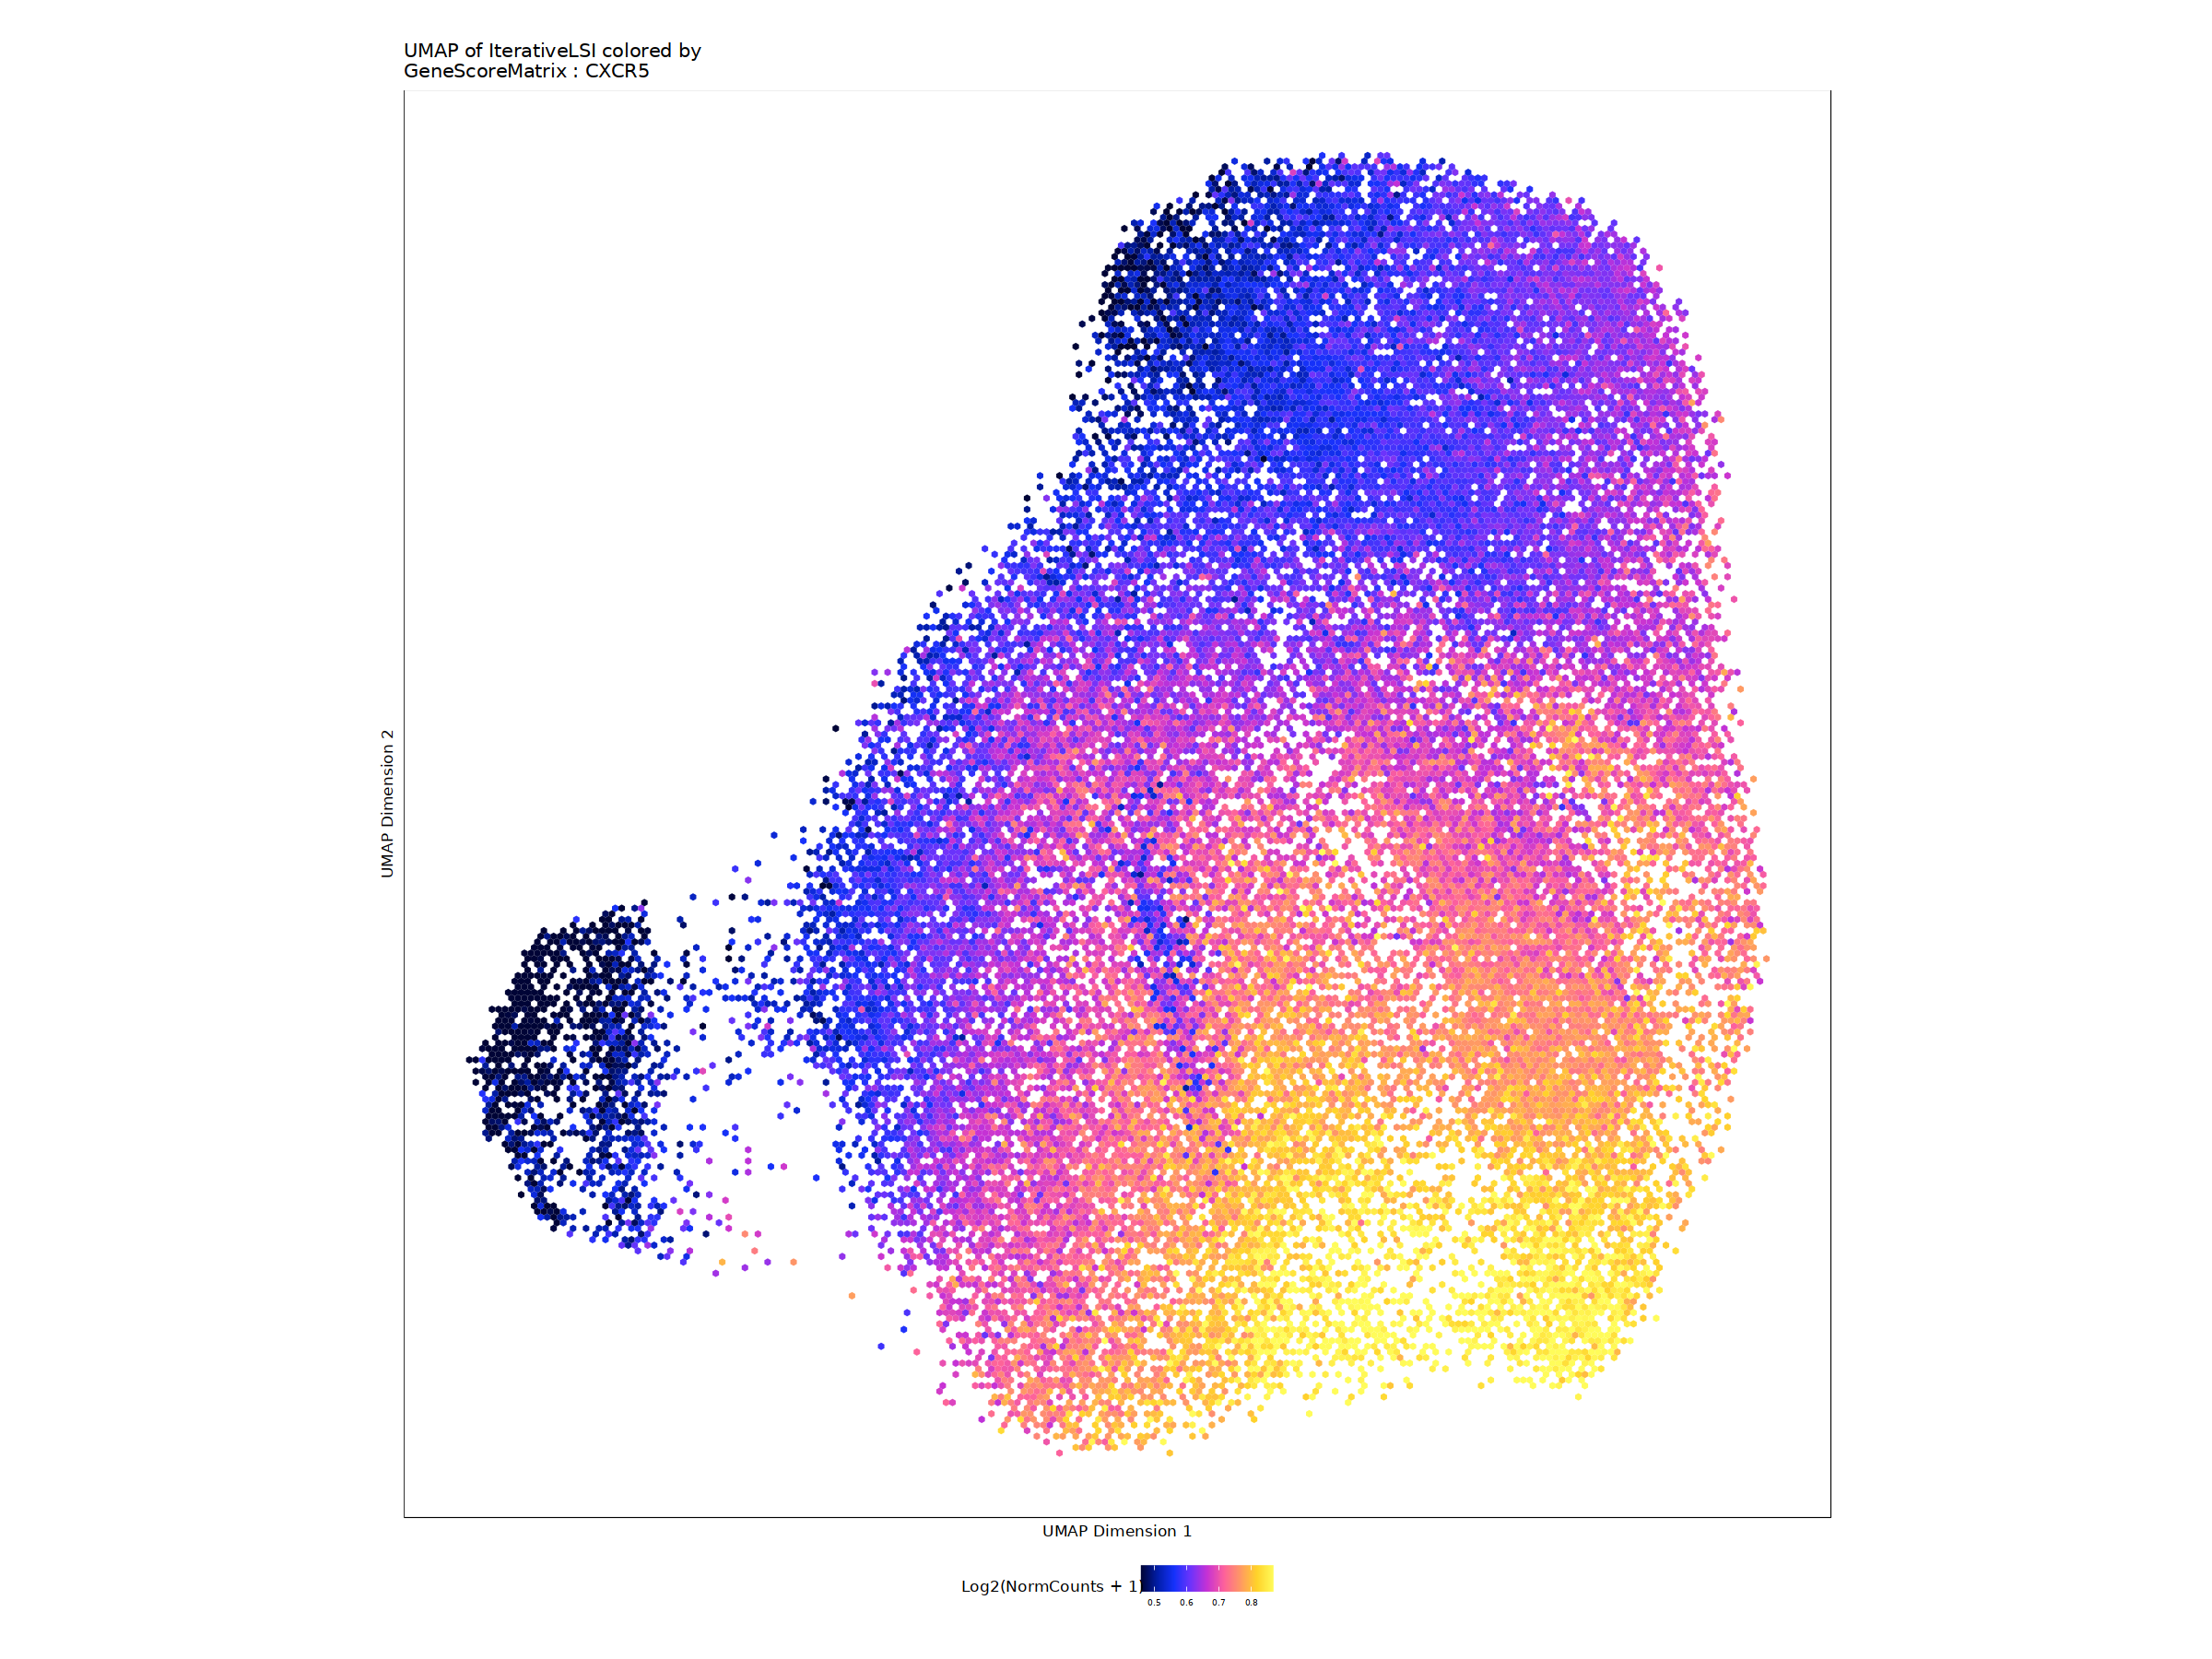

In [ ]:
# plot peaks
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = c("CXCR5"),
    embedding = "UMAP"
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_CXCR5_genes_scores.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 3, height = 3
)


Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-17905834533e-Date-2024-08-14_Time-18-33-07.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2024-08-14 18:33:07 : 



Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-17905834533e-Date-2024-08-14_Time-18-33-07.log

Plotting Ggplot!



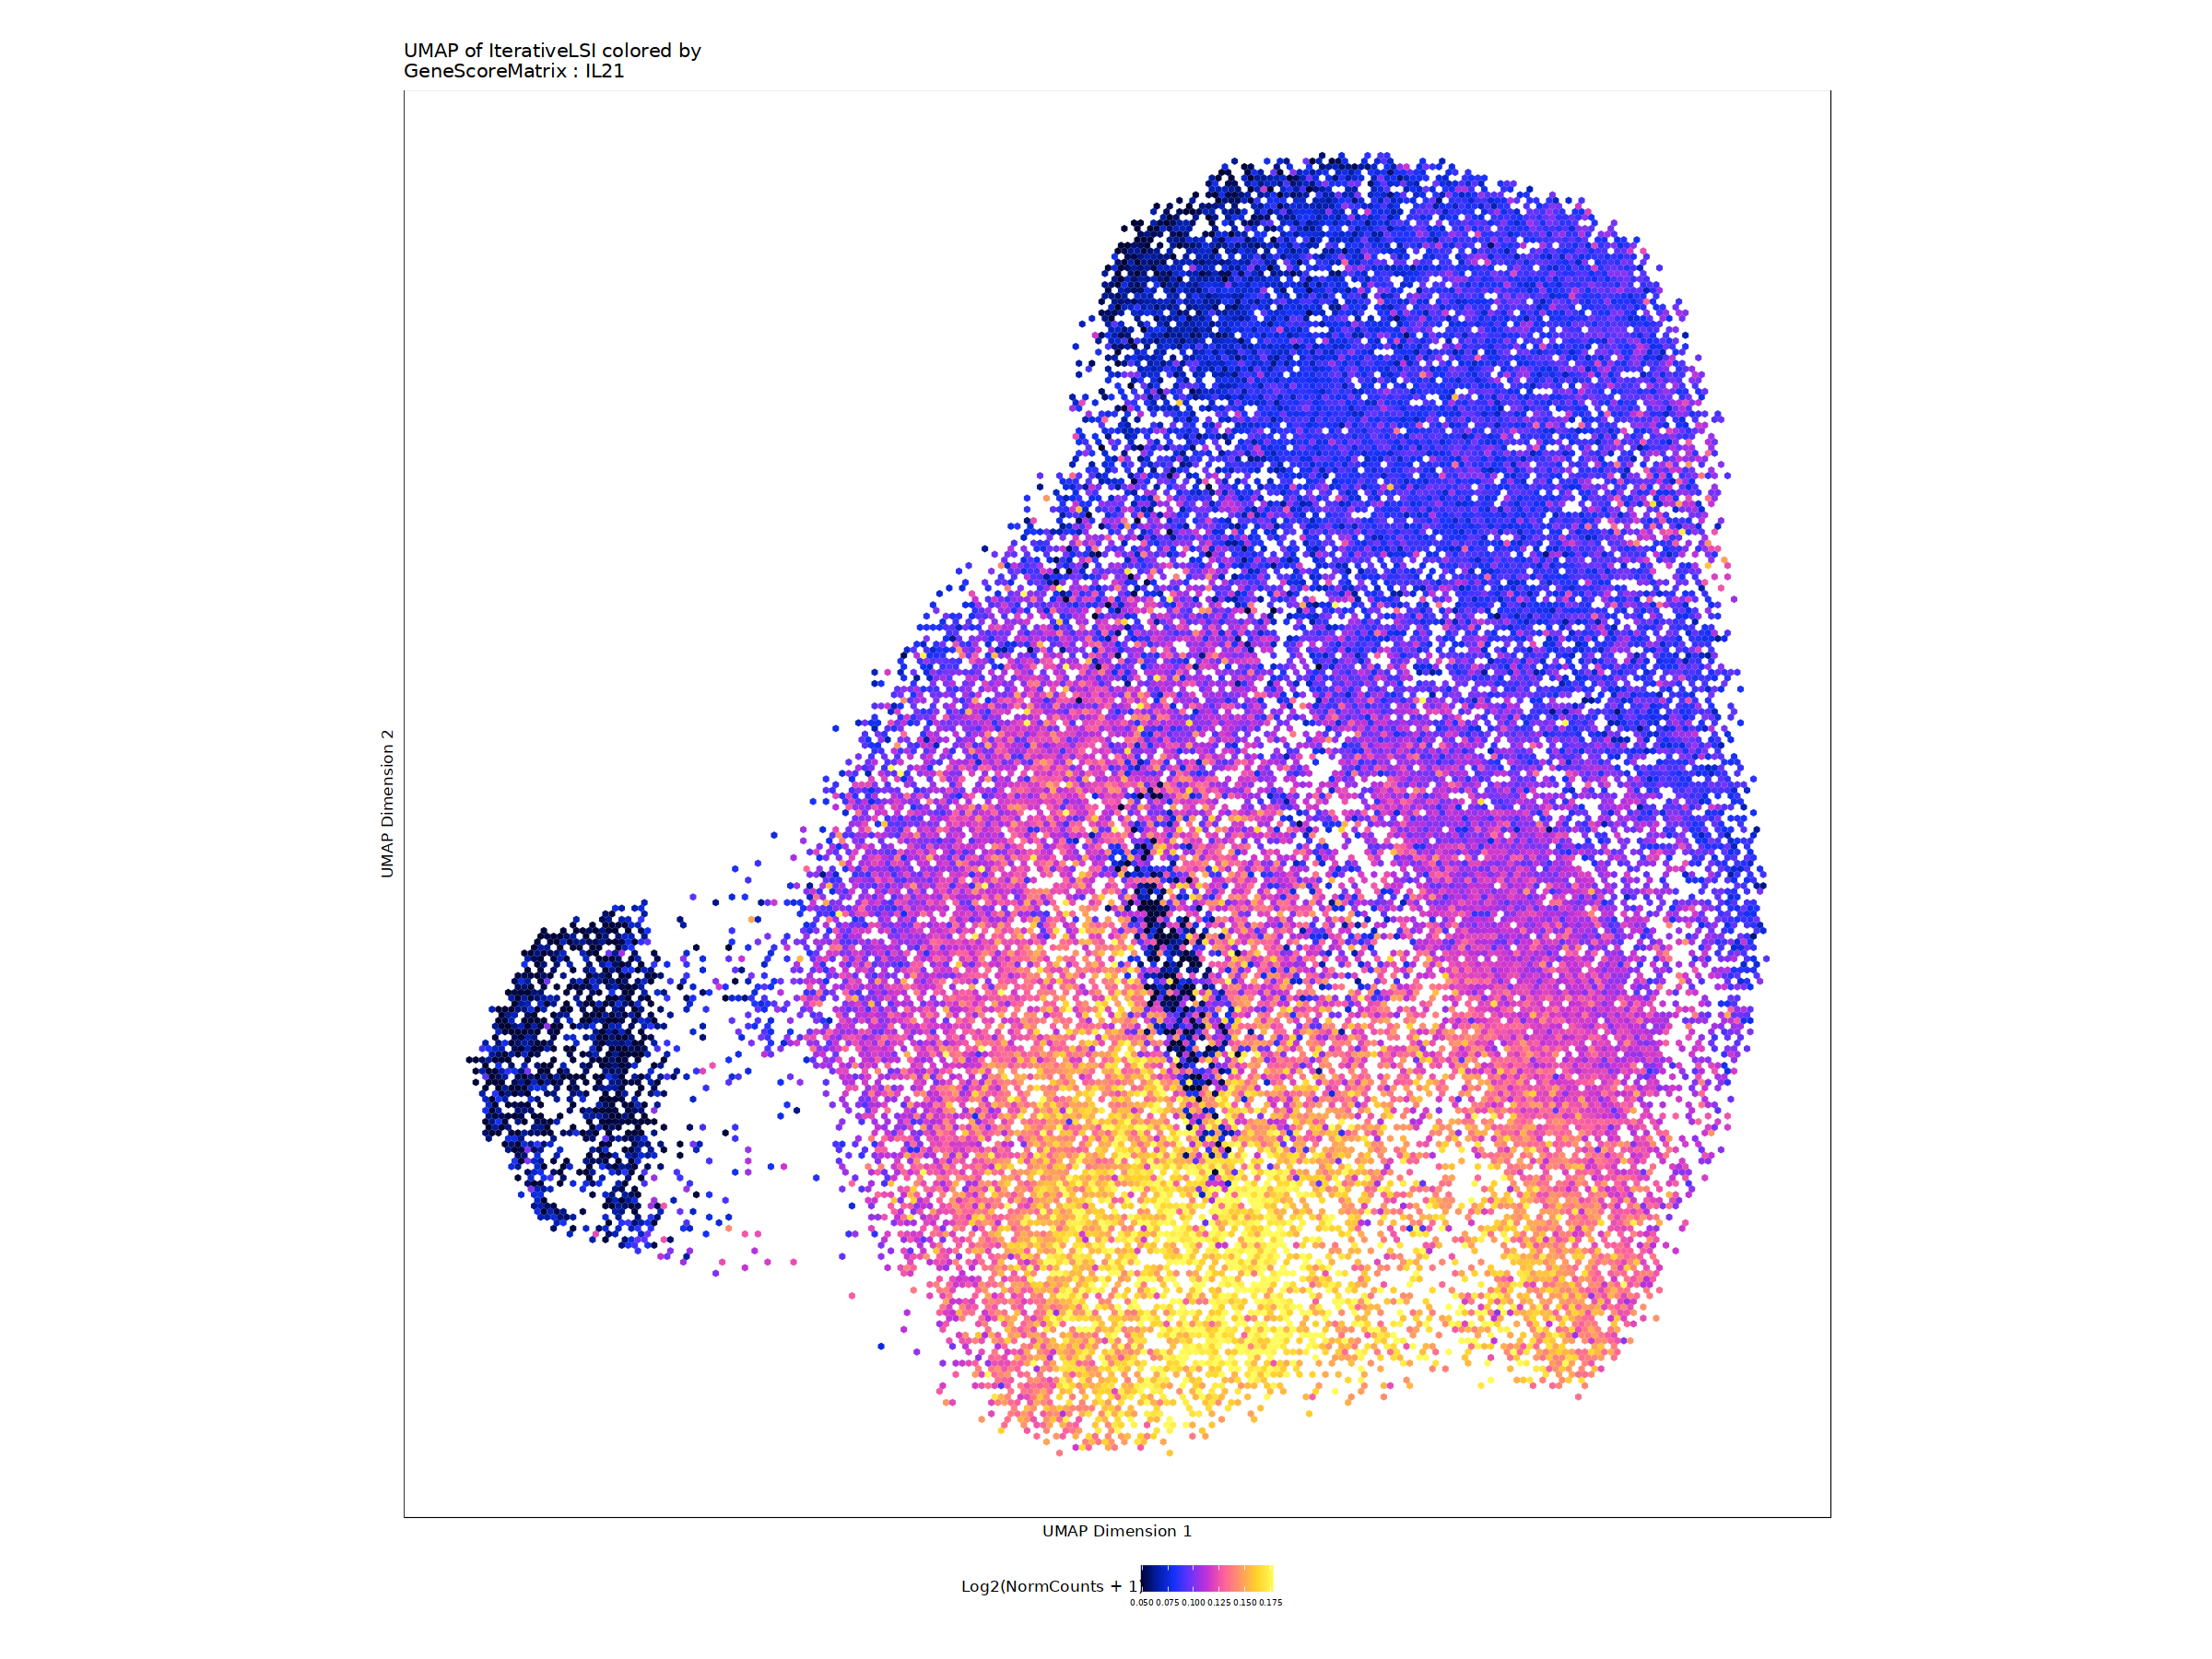

In [ ]:
# plot ppeaks
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = c("IL21"),
    embedding = "UMAP",
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_IL21_genes_scores.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 3, height = 3
)


In [ ]:
getAvailableMatrices(cd4t_atac)


In [ ]:
# test for gene scores difference in C1 ve rest
addArchRThreads(58)
markersGS <- getMarkerFeatures(
    ArchRProj = cd4t_atac,
    useMatrix = "GeneScoreMatrix",
    groupBy = "atac_anno",
    maxCells = 1500,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)


In [ ]:
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.01 & Log2FC >= 1")


In [ ]:
markerList %>% saveRDS(file.path(output_path, paste0(proj_name, "_annotated_celltypes_marker_genes.rds")))


In [ ]:
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = "IL17A",
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p1


In [ ]:
# # plot IL17RA
# #genes_plot = c('ICOS', 'PDCD1', 'CXCR5', 'IL21', 'IL17RA', )
# genes_plot = c('CXCL13', 'IL17A', 'IL23R')
# lapply(genes_plot, function(gene_name){
#     p1 <- plotEmbedding(
#         ArchRProj = cd4t_atac,
#         colorBy = "GeneScoreMatrix",
#         name = gene_name,
#         embedding = "UMAP",
#         #imputeWeights = getImputeWeights(cd4t_atac)
#     )
#     p2 <- plotEmbedding(
#         ArchRProj = cd4t_atac,
#         colorBy = "GeneExpressionMatrix",
#         name = gene_name,
#         embedding = "UMAP",
#         #imputeWeights = getImputeWeights(cd4t_atac)
#     )

#     plotPDF(p1,p2, name = paste0(proj_name, gene_name,'_atac_umap_marker_genes_score_expression.pdf'),
#             ArchRProj = cd4t_atac,
#             addDOC = FALSE, width = 6, height = 6)
# })


In [ ]:
marker_table <- names(markerList) %>%
    lapply(function(x) {
        markergenes <- markerList[[x]] %>%
            as_tibble() %>%
            mutate(cell_type = x)
        return(markergenes)
    }) %>%
    rbindlist()


In [ ]:
top_genes <- marker_table %>%
    arrange(desc(Log2FC)) %>%
    group_by(cell_type) %>%
    slice_max(order_by = Log2FC, n = 10)
marker_table %>% filter(name == "FOXP3")


In [ ]:
markerGenes <- c(
  "CD3D", "CD8A", "TBX21", "IL7R", "CCR7", "IKZF2", "CD25", "GZMB", "CXCR5"
)

heatmapGS <- plotMarkerHeatmap(
  seMarker = markersGS,
  cutOff = "FDR <= 0.01 & Log2FC >= 1.25",
  labelMarkers = markerGenes,
  transpose = TRUE
)


In [ ]:
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")
plotPDF(heatmapGS, name = "GeneScores-Marker-Heatmap", width = 8, height = 6, ArchRProj = cd4t_atac, addDOC = FALSE)


## test daps by atac clusters


In [ ]:
cd4t_atac$Clusters_0.8 %>% table()


.
  C1  C10  C11   C2   C3   C4   C5   C6   C7   C8   C9 
4007 4199 1710 1820 1579 6493 3760 4047 5518 6269 5404 

In [ ]:
# test for gene scores difference in C1 ve rest
addArchRThreads(58)
markersGS <- getMarkerFeatures(
    ArchRProj = cd4t_atac,
    useMatrix = "GeneScoreMatrix",
    groupBy = "Clusters_0.8",
    maxCells = 1579,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)


In [ ]:
markersGS %>% saveRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_genes.rds")))


In [ ]:
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.05")
markerList$C2


In [ ]:
# markerList$C2%>%as_tibble()


In [ ]:
p <- plotDensity(cd4t_atac, embeddingName = "UMAP", identity = "cohort", returnObj = TRUE)
cowplot::plot_grid(plotlist = p)
ggsave(
    filename = file.path(
        getOutputDirectory(cd4t_atac),
        paste0("Plots/", proj_name, "atac_density_umap.pdf")
    ),
    width = 12, height = 6
)


In [ ]:
# test for gene scores difference in C1 ve rest
addArchRThreads(58)
markersPeaks <- getMarkerFeatures(
    ArchRProj = cd4t_atac,
    useMatrix = "PeakMatrix",
    groupBy = "Clusters_0.8",
    maxCells = 1579,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)


In [ ]:
markersPeaks %>% saveRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_peaks.rds")))


In [ ]:
markersPeaks <- readRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_peaks.rds")))


In [ ]:
markersPeaks


In [ ]:
peakList <- getMarkers(markersPeaks, cutOff = "FDR <= 0.01", returnGR = TRUE)


In [ ]:
c1_peaks <- peakList$C1 %>%
    MOCHA::annotateTiles(TxDb = TxDb, Org = Org)
c2_peaks <- peakList$C2 %>%
    MOCHA::annotateTiles(TxDb = TxDb, Org = Org)


In [ ]:
c2_peaks %>% filter(str_detect(Gene, "IL21|CXCR5"))
c1_peaks %>% filter(str_detect(Gene, "PDCD1|CXCL13"))


In [ ]:
c1_c2_share_peaks <- subsetByOverlaps(c1_peaks, c2_peaks, type = "equal")


In [ ]:
c1_c2_share_peaks


In [ ]:
c1_c2_share_peaks %>% filter(str_detect(Gene, "SMAD3"))


In [ ]:
c1_c2_share_genes <- c1_c2_share_peaks %>%
    as_tibble() %>%
    pull(Gene) %>%
    str_split(", ") %>%
    unlist() %>%
    unique()
# pathway enrichment for cd4na
enrich_c1_c2_share <- enrichr(c1_c2_share_genes, c("KEGG_2021_Human", "MSigDB_Hallmark_2020"))
# enrich_c1_c2_share[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)%>%select(Term, Overlap, Adjusted.P.value, Genes)


In [ ]:
enrich_c1_c2_share[["MSigDB_Hallmark_2020"]] %>%
    as_tibble() %>%
    filter(Adjusted.P.value < 0.05) %>%
    dplyr::select(Term, Overlap, Adjusted.P.value, Genes)


In [ ]:
c1_c2_share_genes %>% str_subset("IL\\d|PDCD|CD\\d|TGFB1|SMAD|KLF")


In [ ]:
c1_c2_share_peaks %>% filter(str_detect(Gene, "TGFB1|SMAD|KLF|CXCR"))


In [ ]:
heatmapPeaks <- plotMarkerHeatmap(
  seMarker = markersPeaks,
  cutOff = "FDR <= 0.05 & Log2FC >= 0.5",
  transpose = TRUE,
  labelMarkers = c(
    "chr11:118892500-118892999", "chr19:41351500-41351999", "chr19:41351000-41351499",
    "chr2:241858500-241858999",
    "chr22:17084500-17084999", "chr22:17085000-17085499"
  )
)


In [ ]:
# heatmapPeaks%>%str()


In [ ]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")


In [ ]:
plotPDF(heatmapPeaks, name = "peaks-Clusters_0.8-Heatmap", width = 8, height = 6, ArchRProj = cd4t_atac, addDOC = FALSE)


In [ ]:
library(GenomicRanges)
IL21 <- GRanges(
    seqnames = "chr4",
    ranges = IRanges(start = 122617500, end = 122617999)
)
IL21
# rowData(markersPeaks)%>%subsetByOverlaps(IL21)


In [ ]:
p <- plotBrowserTrack(
    ArchRProj = cd4t_atac,
    groupBy = "Clusters_0.8",
    geneSymbol = c("IL21"),
    features = IL21,
    upstream = 500,
    downstream = 500,
    scCellsMax = 1000,
)


In [ ]:
grid::grid.newpage()
grid::grid.draw(p$IL21)


In [ ]:
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "PeakMatrix",
    name = "chr4:122617500-122617999",
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)


In [ ]:
# plot IL17RA
gene_name <- c(
    "CXCR5", "IL21", "CXCL13", "BCL6", "IL17RA", "TBX21", "KLRB1", "PDCD1", "RORA",
    "ICOS", "CD69", "IL2", "KLF2", "ID3", "ASCL2", "NFIA", "TCF12", "PRDM1"
)
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = gene_name,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_marker_genes_scores.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 4, height = 4
)


In [ ]:
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = "IL17RA",
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_IL17RA_genes_scores.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 5, height = 5
)


In [ ]:
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = "PDCD1",
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_PDCD1_genes_scores.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 5, height = 5
)


In [ ]:
# plot IL17RA
gene_name <- c(
    "CXCR5", "IL21", "CXCL13", "BCL6", "IL17RA", "TBX21", "KLRB1", "PDCD1", "RORA",
    "ICOS", "CD69", "IL2", "KLF2", "ID3", "ASCL2", "NFIA", "TCF12", "PRDM1"
)
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = gene_name,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p1
plotPDF(p1,
    name = paste0(proj_name, "_atac_umap_marker_genes_scores.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 5, height = 5
)


In [ ]:
# export the gene score matrix
gene_scores_mx <- getMatrixFromProject(cd4t_atac,
    useMatrix = "GeneScoreMatrix",
    useSeqnames = NULL,
    verbose = TRUE,
    binarize = FALSE,
    threads = getArchRThreads(),
    logFile = createLogFile("getMatrixFromProject")
)


In [ ]:
# rowData(gep1ne_scores_mx)$name


In [ ]:
# plot individual gene and gene scores
gene_name <- "PRDM1"
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = gene_name,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p2 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = gene_name,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
plotPDF(p1, p2,
    name = paste0(proj_name, gene_name, "_atac_umap_marker_genes_score_expression.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
# plot umap of annotated cell types
marker_genes <- c("IL21", "IL21R")
p3 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = marker_genes,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
p3
plotPDF(p3,
    name = paste0(proj_name, "_atac_umap_marker_IL21_genes_score.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
# plot umap of annotated cell types
marker_genes <- c("GATA3", "RORC", "FOXP3", "TBX21", "IKZF2", "STAT3", "IL23R", "IL17RA")
p3 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = marker_genes,
    embedding = "UMAP",
    # imputeWeights = getImputeWeights(cd4t_atac)
)
plotPDF(p3,
    name = paste0(proj_name, "_atac_umap_marker_genes_score.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
p3


In [ ]:
DefaultAssay(ra_tea_cd4) <- "SCT"
marker_genes %in% rownames(ra_tea_cd4)
rownames(ra_tea_cd4) %>% str_subset("IL17")


In [ ]:
# plot umap of annotated cell types
marker_genes <- c(
    "IFNG-AS1", "IL17A", "IL17F", "IL22", "IFNG",
    "IL4", "CSF2", "IL12A", "IL10", "IL5", "IL13", "TGFBR1"
)
# marker_genes <- c('PLCG2', 'CD3G', 'CD27', )
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = marker_genes,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p2 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = marker_genes[marker_genes != "IL17A"],
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
plotPDF(p1, p2,
    name = paste0(proj_name, "_atac_umap_marker_plcg2_genes_score_imputed_gex.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
# plot umap of annotated cell types
marker_genes <- c("PLCG2", "TGFBR3")
# marker_genes <- c('PLCG2', 'CD3G', 'CD27', )
p1 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = marker_genes,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p2 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = marker_genes,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
plotPDF(p1, p2,
    name = paste0(proj_name, "_atac_umap_marker_", marker_genes, "_genes_score_imputed_gex.pdf"),
    ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
p1
p2


In [ ]:
# p1 <- plotEmbedding(
#     ArchRProj = cd4t_atac,
#     colorBy = "GeneScoreMatrix",
#     name = marker_genes,
#     embedding = "UMAP",
#     imputeWeights = getImputeWeights(cd4t_atac)
# )
p2 <- lapply(p1, function(x) {
    x + guides(color = FALSE, fill = FALSE) +
        theme_ArchR(baseSize = 6.5) +
        theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
        theme(
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        )
})
do.call(cowplot::plot_grid, c(list(ncol = 4), p2))
ggsave(paste0(fig_path, "/", proj_name, "_atac_umap_marker_cytokines_genes_scores.png"), width = 12, height = 8)


In [ ]:
# plot umap of annotated cell types
marker_genes <- c("GATA3", "RORC", "FOXP3", "TBX21", "IKZF2", "STAT3", "RORA", "IFNG-AS1", "CCL5", "IL21", "CXCR5")
p3 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = marker_genes,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p3

plotPDF(p3,
    name = paste0(proj_name, "_atac_umap_marker_cytokines_genes_GeneExpression_imputed.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
# plot umap of annotated cell types
marker_genes <- c("GATA3", "RORC", "FOXP3", "TBX21", "IKZF2", "STAT3", "RORA", "IFNG-AS1", "CCL5", "IL21", "CXCR5")
p3 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = marker_genes,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p3

plotPDF(p3,
    name = paste0(proj_name, "_atac_umap_marker_cytokines_genes_GeneExpression_imputed.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
cd4t_atac <- addClusters(
  input = cd4t_atac,
  reducedDims = "IterativeLSI",
  method = "Seurat",
  name = "Clusters_0.8",
  resolution = 0.8,
  force = TRUE
)


In [ ]:
cellColData(cd4t_atac) %>% colnames()


In [ ]:
cd4t_atac


In [ ]:
getCellColData(cd4t_atac) %>% colnames()


In [ ]:
getOutputDirectory(cd4t_atac)


In [ ]:
p <- plotEmbedding(cd4t_atac,
    embedding = "UMAP",
    colorBy = "cellColData", name = c("clean_l2_cell_types")
)
png(filename = file.path())
p
# plotPDF(p, name = paste0(proj_name, '_atac_umap_Clusters_0.8.pdf'), ArchRProj = cd4t_atac,
#         addDOC = FALSE, width = 6, height = 6)


In [ ]:
cd4t_atac$clean_l2_cell_types %>% table()
cd4t_atac$Clusters_0.8 %>% table()


In [ ]:
# label t mem cell type by atac data
cd4t_atac$t_anno_atac <- case_when(
    cd4t_atac$clean_l2_cell_types == "treg" ~ "treg",
    cd4t_atac$clean_l2_cell_types == "cd4_ctl" ~ "cd4_ctl",
    cd4t_atac$Clusters_0.8 %in% c("C5", "C6") ~ "cd4_naive_ra",
    cd4t_atac$Clusters_0.8 %in% c("C3", "C4", "C7") ~ "cd4_naive",
    cd4t_atac$Clusters_0.8 %in% c("C8", "C6") ~ "cd4_naive_ra",
    cd4t_atac$Clusters_0.8 %in% c("C5", "C6") ~ "cd4_naive_ra",
)


In [ ]:
saveArchRProject(ArchRProj = cd4t_atac)


In [ ]:
# get umap embedding of cd4 atac
cd4t_atac_umap <- getEmbedding(ArchRProj = cd4t_atac, embedding = "UMAP", returnDF = TRUE)
cd4t_atac_umap <- cd4t_atac_umap %>%
    as_tibble(rownames = "barcodes") %>%
    mutate(barcodes = str_split(barcodes, pattern = "#", simplify = TRUE)[, 2]) %>%
    rename("IterativeLSI#UMAP_Dimension_1" = "UMAP1", "IterativeLSI#UMAP_Dimension_2" = "UMAP2")


In [ ]:
cd4t_atac_umap %>% head()
cd4t_atac_umap %>% write_csv(file.path(output_path, paste0(proj_name, "_archr_umap.csv")))


In [ ]:
# get LSI of cd4 atac
cd4t_atac_lsi <- getReducedDims(cd4t_atac, reducedDims = "IterativeLSI")
cd4t_atac_lsi <- cd4t_atac_lsi %>%
    as_tibble(rownames = "barcodes") %>%
    mutate(barcodes = str_split(barcodes, pattern = "#", simplify = TRUE)[, 2])
cd4t_atac_lsi %>% head()
cd4t_atac_lsi %>% write_csv(file.path(output_path, paste0(proj_name, "_archr_lsi.csv")))


In [ ]:
cd4t_atac


In [ ]:
### run pean


In [ ]:
getAvailableMatrices(cd4t_atac)


In [ ]:
# get motif matrix
cd4t_atac_motif <- getMatrixFromProject(ArchRProj = cd4t_atac, useMatrix = "MotifMatrix")


In [ ]:
cd4t_atac_motif


In [ ]:
cd4t_atac_motif <- as(cd4t_atac_motif, "SingleCellExperiment")


In [ ]:
colnames(cd4t_atac_motif) <- str_split(colnames(cd4t_atac_motif), pattern = "#", simplify = TRUE)[, 2]


In [ ]:
cd4t_atac_motif


In [ ]:
# assay(cd4t_atac_motif, 'deviations')


In [ ]:
file.path(
    output_path,
    paste0(proj_name, "_chromvar_motif_activity.h5ad")
)


In [ ]:
# save the file to anndata
sceasy::sce2anndata(cd4t_atac_motif,
    from = "sce", to = "anndata",
    main_layer = "deviations", transfer_layers = "z",
    outFile = file.path(
        output_path,
        paste0(proj_name, "_chromvar_motif_activity.h5ad")
    )
)


In [ ]:
# get motif z scores from atac
cd4t_atac_motif_zscore <- assay(cd4t_atac_motif, "z") %>%
    t() %>%
    as_tibble() %>%
    mutate(index = str_split(colnames(cd4t_atac_motif), pattern = "#", simplify = TRUE)[, 2])


In [ ]:
cd4t_atac_motif_zscore %>% head()
cd4t_atac_motif_zscore %>% write_csv(file.path(output_path, paste0(proj_name, "_chromvar_motif_zscore.csv")))


### import peaks called by mocha into archr


In [ ]:
SampleTileMatricesAnnotated


In [ ]:
# SampleTileMatricesAnnotated %>% rownames() %>% unique()


In [ ]:
# make a grange object from the the union of the peaks called
granges_mocha <- SampleTileMatricesAnnotated %>%
    rownames() %>%
    unique() %>%
    StringsToGRanges()
granges_mocha


In [ ]:
rowData(SampleTileMatricesAnnotated)$cd4_naive %>% unique()


In [ ]:
# add the peak called by scMACS back to archR
cd4t_atac <- addPeakSet(
  ArchRProj = cd4t_atac,
  peakSet = granges_mocha,
  genomeAnnotation = getGenomeAnnotation(cd4t_atac),
  force = TRUE
)
cd4t_atac <- addPeakMatrix(cd4t_atac)


In [ ]:
## Create new feature matrix for mocha call peaks
cd4t_atac <- addFeatureMatrix(cd4t_atac,
    matrixName = "MochaPeakMatrix",
    features = granges_mocha, binarize = FALSE
)


In [ ]:
cd4t_atac <- addBgdPeaks(cd4t_atac, force = TRUE)


In [ ]:
names(cd4t_atac@peakAnnotation)
getAvailableMatrices(cd4t_atac)


In [ ]:
cd4t_atac <- ArchR::addMotifAnnotations(
    ArchRProj = cd4t_atac, force = TRUE,
    motifSet = "cisbp", name = "Motif"
)


In [ ]:
cd4t_atac <- addDeviationsMatrix(
  ArchRProj = cd4t_atac,
  peakAnnotation = "Motif",
  force = TRUE
)


In [ ]:
saveArchRProject(ArchRProj = cd4t_atac)


In [ ]:
plotVarDev <- getVarDeviations(cd4t_atac, name = "MotifMatrix", plot = TRUE)
plotVarDev


In [ ]:
motif_div <- getVarDeviations(cd4t_atac, name = "MotifMatrix", plot = FALSE) %>%
    as_tibble()


In [ ]:
motif_div %>% filter(str_detect(name, "MAF|BCL6|PRDM1"))


In [ ]:
motifs <- c("GATA3", "RORC", "FOXP3", "TBX21", "IKZF2", "STAT3", "STAT4", "STAT5B", "STAT6", "MAF", "BCL6")
# motifs <-plotVarDev %>% as_tibble() %>% distinct(name) %>% pull(name)
markerMotifs <- getFeatures(cd4t_atac, select = paste(motifs, collapse = "|"), useMatrix = "MotifMatrix")
markerMotifs
markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs


In [ ]:
motifs <- c("RORC", "TBX21", "IKZF2", "STAT3", "STAT5", "BCL6", "PRDM1", "JUND", "SOX4")
# motifs <-plotVarDev %>% as_tibble() %>% distinct(name) %>% pull(name)
markerMotifs <- getFeatures(cd4t_atac, select = paste(motifs, collapse = "|"), useMatrix = "MotifMatrix")
markerMotifs
markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs


In [ ]:
p <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "MotifMatrix",
    name = sort(markerMotifs),
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p
plotPDF(p,
    name = paste0(proj_name, "_atac_umap_chrovar_motif.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
p2 <- lapply(p, function(x) {
    x + guides(color = FALSE, fill = FALSE) +
        theme_ArchR(baseSize = 6.5) +
        theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
        theme(
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        )
})
do.call(cowplot::plot_grid, c(list(ncol = 3), p2))


In [ ]:
getAvailableMatrices(cd4t_atac)


In [ ]:
p3 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneExpressionMatrix",
    name = motifs,
    embedding = "UMAP",
    imputeWeights = NULL # getImputeWeights(cd4t_atac)
)


In [ ]:
p3 <- lapply(p3, function(x) {
    x + guides(color = FALSE, fill = FALSE) +
        theme_ArchR(baseSize = 6.5) +
        theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
        theme(
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        )
})
do.call(cowplot::plot_grid, c(list(ncol = 3), p3))


In [ ]:
p4 <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = motifs,
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
p4 <- lapply(p4, function(x) {
    x + guides(color = FALSE, fill = FALSE) +
        theme_ArchR(baseSize = 6.5) +
        theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
        theme(
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        )
})
do.call(cowplot::plot_grid, c(list(ncol = 3), p4))


In [ ]:
# plot cytokines gene scroes
p <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "GeneScoreMatrix",
    name = sort(markerMotifs),
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)
plotPDF(p,
    name = paste0(proj_name, "_atac_umap_chrovar_motif.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 6, height = 6
)


In [ ]:
cd4t_atac


In [ ]:
p <- plotEmbedding(
    ArchRProj = cd4t_atac,
    colorBy = "MotifMatrix",
    name = sort(markerMotifs),
    embedding = "UMAP",
    imputeWeights = getImputeWeights(cd4t_atac)
)


## analyze cluster in atac data


In [ ]:
cd4t_atac$Clusters_0.8 %>% table()
getCellColData(cd4t_atac) %>% colnames()


.
  C1  C10  C11   C2   C3   C4   C5   C6   C7   C8   C9 
4007 4199 1710 1820 1579 6493 3760 4047 5518 6269 5404 

[1] "barcodes"             "Sample"               "well_id"             
 [4] "TSSEnrichment"        "tss_frac"             "tss_count"           
 [7] "singlet"              "ReadsInTSS"           "ReadsInPromoter"     
[10] "ReadsInBlacklist"     "PromoterRatio"        "pool_id"             
[13] "peaks_frac"           "peaks_count"          "pbmc_sample_id"      
[16] "PassQC"               "original_barcodes"    "NucleosomeRatio"     
[19] "nMultiFrags"          "nMonoFrags"           "nFrags"              
[22] "nDiFrags"             "n_unique"             "n_mito"              
[25] "n_fragments"          "n_duplicate"          "gene_bodies_frac"    
[28] "gene_bodies_count"    "DoubletScore"         "DoubletEnrichment"   
[31] "chip_id"              "cell_name"            "BlacklistRatio"      
[34] "batch_id"             "altius_frac"          "altius_count"        
[37] "Clusters"             "subject_id"           "cohort"              
[40] "Birth.Year"           "Sex"                  "wsnn_res.0.5"        
[43] "l1_cell_types"        "l2_cell_types"        "clean_l2_cell_types" 
[46] "ReadsInPeaks"         "FRIP"                 "MochaPeak_clusters_1"
[49] "Clusters_0.5"         "Clusters_0.8"         "CD4TnaC2toC1"

In [ ]:
atac_cluster_0.8 <- getCellColData(cd4t_atac) %>%
    as_tibble() %>%
    dplyr::select(c(barcodes, Clusters_0.8)) %>%
    dplyr::rename("Archr_Clusters_0_8" = "Clusters_0.8")
atac_cluster_0.8 %>% head()
atac_cluster_0.8 %>% write_csv(file.path(output_path, paste0(proj_name, "_Clusters_0.8_cluster_barcodes.csv")))


barcodes,Archr_Clusters_0_8
<chr>,<chr>
036ca36a867711ec812e8a03b6f8af59,C1
09bf48e4867711ec812e8a03b6f8af59,C1
16d7cc0e867711ec88c9261fc224e123,C2
247a319e867711ecb986e6bd662d34f1,C2
7de850ce867911ec917f9ac5a7a60c44,C2
782825ee867711ecbf92d61b4111cf57,C2


In [ ]:
# get cluster frequency and plot
cluster_freq <- GetClusterFreq(cd4t_atac,
    cluster_name = "Clusters_0.8",
    meta_cols = c("cohort"), sample_col = "subject_id"
) %>%
    mutate(cohort = recode(cohort, "Healthy" = "CON2", "pre-RA" = "ARI") %>% factor(levels = c("CON2", "ARI")))
cluster_freq %>% head()


Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”
`summarise()` has grouped output by 'Clusters_0.8', 'subject_id'. You can
override using the `.groups` argument.


Clusters_0.8,subject_id,counts,frequency,cohort
<chr>,<chr>,<int>,<dbl>,<fct>
C1,BR1019,268,0.05991505,CON2
C1,BR1031,161,0.04794521,CON2
C1,BR2018,186,0.04967949,CON2
C1,BR2029,354,0.09178118,CON2
C1,BR2034,278,0.08176471,CON2
C1,CU1002,203,0.05366112,ARI


In [ ]:
# Defnie a function to do clr transformatin from frequency table
FreqClrTran <- function(freq_table, freq_col = "frequency_live", celltype_col = "labels", sample_col = "sample_id",
                        clr_name = "clr") {
    require("compositions")
    freq <- freq_table %>%
        dplyr::select(all_of(c(freq_col, celltype_col, sample_col))) %>%
        pivot_wider(
            id_cols = all_of(sample_col), names_from = all_of(celltype_col),
            values_from = all_of(freq_col), values_fill = 0
        )
    freq_mx <- freq %>%
        dplyr::select(-all_of(sample_col)) %>%
        as.matrix()
    rownames(freq_mx) <- freq[[sample_col]]
    freq_clr <- compositions::clr(freq_mx) %>%
        as_tibble(rownames = sample_col) %>%
        pivot_longer(cols = c(-all_of(sample_col)), names_to = celltype_col, values_to = clr_name)
    freq_meta_clr <- freq_table %>% full_join(freq_clr, by = c(sample_col, celltype_col))
    return(freq_meta_clr)
}
cluster_freq <- FreqClrTran(cluster_freq,
    freq_col = "frequency",
    celltype_col = "Clusters_0.8", clr_name = "clr",
    sample_col = "subject_id"
) %>%
    mutate(Clusters_0.8 = factor(Clusters_0.8, levels = paste0("C", 1:11)))


Loading required package: compositions

Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following objects are masked from ‘package:IRanges’:

    cor, cov, var


The following objects are masked from ‘package:S4Vectors’:

    cor, cov, var


The following objects are masked from ‘package:BiocGenerics’:

    normalize, var


The following object is masked from ‘package:Matrix’:

    norm


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




In [ ]:
cluster_freq %>% head()
cluster_freq$Clusters_0.8 %>% levels()


Clusters_0.8,subject_id,counts,frequency,cohort,clr
<fct>,<chr>,<int>,<dbl>,<fct>,<dbl>
C1,BR1019,268,0.05991505,CON2,0.14370079
C1,BR1031,161,0.04794521,CON2,-0.07134016
C1,BR2018,186,0.04967949,CON2,-0.03746386
C1,BR2029,354,0.09178118,CON2,0.34385572
C1,BR2034,278,0.08176471,CON2,0.47014923
C1,CU1002,203,0.05366112,ARI,-0.25171355


[1] "C1"  "C2"  "C3"  "C4"  "C5"  "C6"  "C7"  "C8"  "C9"  "C10" "C11"

In [ ]:
# run test
cluster_freq_wilcox <- cluster_freq %>%
  group_by(Clusters_0.8) %>%
  wilcox_test(clr ~ cohort) %>%
  adjust_pvalue(method = "BH") %>%
  add_significance()
cluster_freq_wilcox %>% arrange(p.adj)


Clusters_0.8,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
C5,clr,CON2,ARI,5,7,0,0.00253,0.009276667,**
C6,clr,CON2,ARI,5,7,35,0.00253,0.009276667,**
C10,clr,CON2,ARI,5,7,35,0.00253,0.009276667,**
C9,clr,CON2,ARI,5,7,34,0.00505,0.013887500,*
C2,clr,CON2,ARI,5,7,2,0.01010,0.022220000,*
C4,clr,CON2,ARI,5,7,30,0.04800,0.088000000,ns
C8,clr,CON2,ARI,5,7,28,0.10600,0.166571429,ns
C1,clr,CON2,ARI,5,7,10,0.26800,0.368500000,ns
C7,clr,CON2,ARI,5,7,23,0.43200,0.528000000,ns


In [ ]:
sig_cluster <- cluster_freq_wilcox %>% filter(p.adj < 0.05)


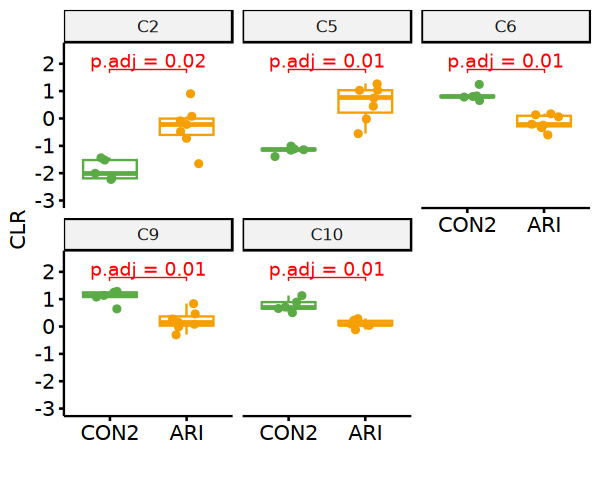

In [ ]:
# plot the frequency compariosns for all the cluters
options(repr.plot.width = 5, repr.plot.height = 4)
p1 <- cluster_freq %>%
    filter(Clusters_0.8 %in% sig_cluster$Clusters_0.8) %>%
    ggpubr::ggboxplot(
        x = "cohort", y = "clr",
        xlab = "", ylab = "CLR",
        palette = ari_colors,
        add = "jitter", color = "cohort"
    ) +
    facet_wrap(vars(factor(Clusters_0.8, levels = paste0("C", 1:11)))) + ylim(-3, 2.5) +
    guides(color = "none")
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
    filter(Clusters_0.8 %in% sig_cluster$Clusters_0.8) %>%
    add_xy_position(x = "cohort") %>%
    mutate(p.adj = round(p.adj, digits = 2))
p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
    label = "p.adj = {p.adj}",
    color = "red", y.position = 1.8
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_sig_clr.pdf")), width = 5, height = 4)


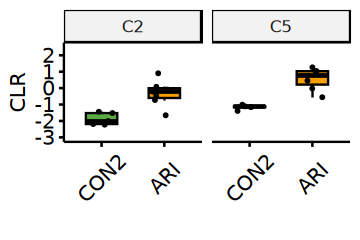

In [ ]:
# plot the frequency compariosns for C2 and C5
options(repr.plot.width = 3, repr.plot.height = 2)
p1 <- cluster_freq %>%
  filter(Clusters_0.8 %in% c("C2", "C5")) %>%
  ggpubr::ggboxplot(
    x = "cohort", y = "clr", fill = "cohort",
    width = 0.5, add.params = list(size = 0.6, alpha = 1),
    xlab = "", ylab = "CLR",
    palette = ari_colors,
    add = "jitter"
  ) +
  facet_wrap(vars(factor(Clusters_0.8, levels = paste0("C", 1:11)))) + ylim(-3, 2.5) +
  guides(fill = "none") +
  theme(axis.text.x = element_text(angle = 45, vjust = .5, hjust = 0.5))
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
  filter(Clusters_0.8 %in% c("C2", "C5")) %>%
  add_xy_position(x = "cohort") %>%
  mutate(p.adj = round(p.adj, digits = 2))
p1
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_C2_C5_clr.pdf")), width = 2, height = 2)


In [ ]:
fig_path


[1] "/home/jupyter/data/preRA_teaseq/EXP-00243/cd4t_cells/Plots"

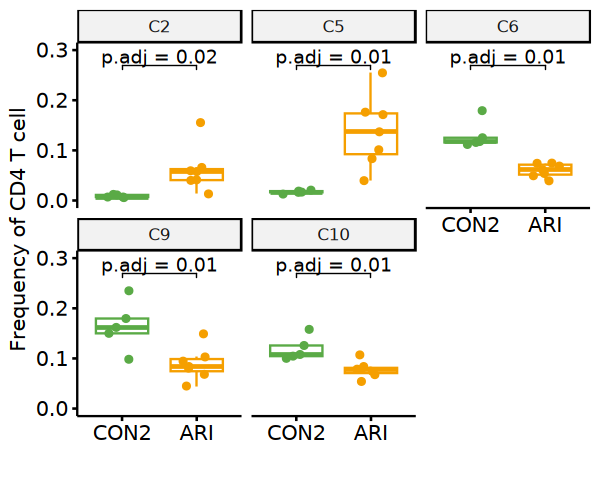

In [ ]:
# plot the frequency compariosns for all the cluters
options(repr.plot.width = 5, repr.plot.height = 4)
p1 <- cluster_freq %>%
    filter(Clusters_0.8 %in% sig_cluster$Clusters_0.8) %>%
    ggpubr::ggboxplot(
        x = "cohort", y = "frequency",
        xlab = "", ylab = "Frequency of CD4 T cell",
        palette = ari_colors,
        add = "jitter", color = "cohort"
    ) +
    facet_wrap(vars(factor(Clusters_0.8, levels = paste0("C", 1:11)))) + ylim(0, 0.3) + guides(color = "none")
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
    filter(Clusters_0.8 %in% sig_cluster$Clusters_0.8) %>%
    add_xy_position(x = "cohort") %>%
    mutate(p.adj = round(p.adj, digits = 2))
p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
    label = "p.adj = {p.adj}",
    y.position = 0.27
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_sig_frequency.pdf")), width = 5, height = 4)


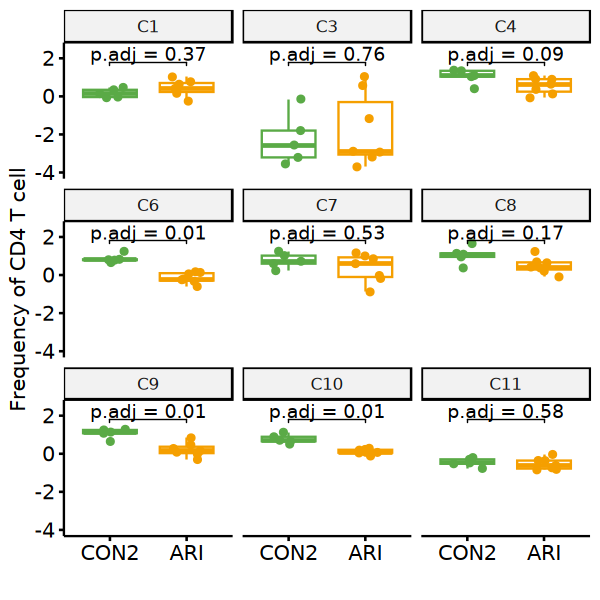

In [ ]:
# plot the frequency compariosns for all the cluters
options(repr.plot.width = 5, repr.plot.height = 5)
p1 <- cluster_freq %>%
    filter(!Clusters_0.8 %in% c("C2", "C5")) %>%
    ggpubr::ggboxplot(
        x = "cohort", y = "clr",
        xlab = "", ylab = "Frequency of CD4 T cell",
        palette = ari_colors,
        add = "jitter", color = "cohort"
    ) +
    facet_wrap(vars(factor(Clusters_0.8, levels = paste0("C", 1:11)))) + ylim(-4, 2.5) +
    guides(color = "none")
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
    filter(!Clusters_0.8 %in% c("C2", "C5")) %>%
    add_xy_position(x = "cohort") %>%
    mutate(p.adj = round(p.adj, digits = 2))
p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
    label = "p.adj = {p.adj}",
    y.position = 1.8
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_nonsig_clr.pdf")), width = 5, height = 5)


In [ ]:
# # plot the frequency compariosns for all the cluters
# p1 <- cluster_freq%>%
# #filter(Clusters_0.8%in%c('C2','C1', 'C5'))%>%
#     ggpubr::ggboxplot(x='cohort', y='clr',
#                       palette=nejm_color,
#                       add = "jitter", color='cohort') +
#     facet_wrap(vars(factor(Clusters_0.8, levels = paste0("C", 1:11))))
# # Add adjusted p-values
# cluster_freq_wilcox.plot <- cluster_freq_wilcox %>% add_xy_position(x = "cohort")%>%
#     mutate(p.adj=round(p.adj, digits = 2))
# p1 + ggpubr::stat_pvalue_manual(cluster_freq_wilcox.plot,
#                         label = "p.adj = {p.adj}",
#                         y.position = 1.6 )
# ggsave(file.path(fig_path, paste0(proj_name, '_Clusters_0.8_clr.png')), width = 12, height = 10)


In [ ]:
p1 <- cluster_freq %>%
    ungroup() %>%
    filter(Clusters_0.8 %in% c("C2", "C5", "C6", "C9", "C10")) %>%
    ggpubr::ggboxplot(
        x = "cohort", y = "frequency", palette = nejm_color, facet.by = "Clusters_0.8",
        add = "jitter", color = "cohort"
    )
# Add adjusted p-values
cluster_freq_wilcox.plot <- cluster_freq_wilcox %>%
    filter(Clusters_0.8 %in% c("C2", "C5", "C6", "C9", "C10")) %>%
    add_xy_position(x = "cohort") %>%
    mutate(p.adj = round(p.adj, digits = 2))
p1 + stat_pvalue_manual(cluster_freq_wilcox.plot,
    label = "p.adj = {p.adj}",
    y.position = 0.25
)
ggsave(file.path(fig_path, paste0(proj_name, "_Clusters_0.8_sig_frequency.png")), width = 12, height = 6)


### analyze peaks and motif in Clusters_0.8


In [ ]:
# test for gene scores difference in C1 ve rest
markersPeak <- getMarkerFeatures(
    ArchRProj = cd4t_atac,
    useMatrix = "PeakMatrix",
    groupBy = "Clusters_0.8",
    maxCells = 1500,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)


In [ ]:
markerList <- getMarkers(markersPeak, cutOff = "FDR <= 0.01 & Log2FC >= 0.5", returnGR = TRUE)


In [ ]:
markerList


In [ ]:
markerList$C2


In [ ]:
peaks_C2 <- markerList$C2 %>%
    as_tibble() %>%
    filter(str_detect(Gene, "IL\\d|CXCR|BCL6|MAF|CD"))


In [ ]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeak,
  cutOff = "FDR <= 0.01 & Log2FC >= 0.5",
  transpose = TRUE
)


In [ ]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")


In [ ]:
pma <- plotMarkers(seMarker = markersPeak, name = "C2", cutOff = "FDR <= 0.1 & abs(Log2FC) >= 1", plotAs = "MA")
pma


In [ ]:
cd4t_atac <- addMotifAnnotations(ArchRProj = cd4t_atac, motifSet = "cisbp", name = "Motif")


### plot motif heatmap


In [ ]:
motifsUp <- peakAnnoEnrichment(
  seMarker = markersPeak,
  ArchRProj = cd4t_atac,
  peakAnnotation = "Motif",
  cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
)


motifsUp


In [ ]:
df <- data.frame(TF = rownames(motifsUp), mlog10Padj = assay(motifsUp)[, 2])
df <- df[order(df$mlog10Padj, decreasing = TRUE), ]
df$rank <- seq_len(nrow(df))
df %>% head()


In [ ]:
enrichMotifs <- peakAnnoEnrichment(
  seMarker = markersPeak,
  ArchRProj = cd4t_atac,
  peakAnnotation = "Motif",
  cutOff = "FDR <= 0.05 & Log2FC >= 0.1"
)


In [ ]:
# assays(enrichMotifs)$Enrichment


In [ ]:
heatmapEM <- plotEnrichHeatmap(enrichMotifs,
    n = 15, pal = paletteContinuous(set = "solarExtra", n = 256, reverse = FALSE),
    clusterCols = TRUE, transpose = TRUE, rastr = FALSE
)


In [ ]:
heatmapEM@top_annotation@anno_list$foo@fun@called_args$labels


In [ ]:
labels <- str_split(heatmapEM@top_annotation@anno_list$foo@fun@called_args$labels,
    pattern = "_", simplify = TRUE
)[, 1]
labels
heatmapEM@top_annotation@anno_list$foo@fun@called_args$labels <- labels


In [ ]:
ComplexHeatmap::draw(heatmapEM, heatmap_legend_side = "bot", annotation_legend_side = "bot")


In [ ]:
plotPDF(heatmapEM,
        name = "motif_enrich-Clusters_0.8-Heatmap",
        width = 6, height = 5, ArchRProj = cd4t_atac, addDOC = FALSE
)


In [ ]:
# test for motif difference in Clusters_0.8
markersMotif <- getMarkerFeatures(
    ArchRProj = cd4t_atac,
    useMatrix = "MotifMatrix",
    groupBy = "Clusters_0.8",
    maxCells = 1500,
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)


In [ ]:
# assay(markersMotif, 'MeanDiff')


In [ ]:
heatmapChromvar <- plotMarkerHeatmap(
  seMarker = markersMotif,
  cutOff = "FDR <= 0.1",
  transpose = TRUE
)


In [ ]:
draw(heatmapChromvar, heatmap_legend_side = "bot", annotation_legend_side = "bot")


In [ ]:
motifList <- getMarkers(markersMotif, cutOff = "FDR <= 0.05 & MeanDiff >= 0.01")


In [ ]:
motifList$C2 %>% as_tibble()


### plot heatmap based on the Chromvar z score


In [ ]:
library(dittoSeq)
library(ComplexHeatmap)


In [16]:
chromvar_motif <- getMatrixFromProject(
  ArchRProj = cd4t_atac,
  useMatrix = "MotifMatrix",
  useSeqnames = NULL,
  verbose = TRUE,
  binarize = FALSE,
  threads = getArchRThreads()
)


ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-1b9a50da9c2-Date-2024-09-14_Time-01-17-28.294373.log
If there is an issue, please report to github with logFile!

2024-09-14 01:18:08.792177 : Organizing colData, 0.675 mins elapsed.

2024-09-14 01:18:10.083123 : Organizing rowData, 0.697 mins elapsed.

2024-09-14 01:18:10.089514 : Organizing rowRanges, 0.697 mins elapsed.

2024-09-14 01:18:10.099853 : Organizing Assays (1 of 2), 0.697 mins elapsed.

2024-09-14 01:18:17.437333 : Organizing Assays (2 of 2), 0.819 mins elapsed.

2024-09-14 01:18:21.016688 : Constructing SummarizedExperiment, 0.879 mins elapsed.

2024-09-14 01:18:22.371103 : Finished Matrix Creation, 0.901 mins elapsed.



In [ ]:
chromvar_motif


class: SummarizedExperiment 
dim: 870 44806 
metadata(0):
assays(2): deviations z
rownames(870): TFAP2B_1 TFAP2D_2 ... TBX18_869 TBX22_870
rowData names(2): idx name
colnames(44806):
  EXP-00243-P1_PB00067-03#2c84c8a6867a11eca0eb22d5f9e68fc5
  EXP-00243-P1_PB00067-03#86273fd4867911ec917f9ac5a7a60c44 ...
  EXP-00243-P1_PB00212-03#60048794867911ecb648ee55e4236e76
  EXP-00243-P1_PB00212-03#1791f35e867711ec88c9261fc224e123
colData names(55): altius_count altius_frac ... Clusters_0.8
  CD4TnaC2toC1

In [ ]:
# calcualte the mean z scroes per cluster
chromvar_motif_mean <- scuttle::summarizeAssayByGroup(chromvar_motif, chromvar_motif$Clusters_0.8,
    statistics = "mean",
    assay.type = "z"
)
rownames(chromvar_motif_mean) <- str_split(rownames(chromvar_motif_mean), "_", simplify = TRUE)[, 1]


In [ ]:
chromvar_motif_mean


class: SummarizedExperiment 
dim: 870 11 
metadata(0):
assays(1): mean
rownames(870): TFAP2B TFAP2D ... TBX18 TBX22
rowData names(0):
colnames(11): C1 C10 ... C8 C9
colData names(2): ids ncells

In [ ]:
tf_selected <- rownames(chromvar_motif_mean) %>% str_subset("NFAT|FOXP3")
tf_selected


[1] "FOXP3"  "NFATC3" "NFATC4" "NFATC2" "NFAT5"  "NFATC1"

In [ ]:
tf_selected <- c(
  "JUND", "JUNB", "JUN", "MAF", "KLF8", "KLF1", "KLF3", "BCL6", "RORC",
  "BCL6B", "NR4A1",
  "ELK3", "ELK1", "ELK4", "SMAD4", "SMAD1", "SMAD2", "STAT1",
  "STAT5A", "STAT4", "STAT6", "STAT3", "STAT2", "STAT5B", "SMAD9",
  "GATA3", "TBX21", "BATF", "IRF4", "FOXP3", "NFATC3", "NFATC2", "NFAT5", "NFATC1"
)
sel_tf_loc <- 1:length(rownames(chromvar_motif_mean))
sel_tf_loc <- sel_tf_loc[rownames(chromvar_motif_mean) %in% tf_selected]
sel_tf <- rownames(chromvar_motif_mean)[rownames(chromvar_motif_mean) %in% tf_selected]

ha <- rowAnnotation(foo = anno_mark(
  at = sel_tf_loc,
  labels = sel_tf, labels_gp = gpar(fontsize = 12)
))


In [ ]:
# plot the heatmap
options(repr.plot.width = 20, repr.plot.height = 15)
# Heatmap visualization - DittoHeatmap
pdf(file.path(fig_path, paste0(proj_name, "motif_heatmap.pdf")), width = 6, height = 9)
p1 <- dittoHeatmap(chromvar_motif_mean,
    assay = "mean",
    cluster_cols = TRUE, complex = TRUE,
    scale = "row",
    annot.colors = cluster_colors,
    right_annotation = ha,
    # annot.by = c("ids"),
    show_rownames = FALSE,
    heatmap.colors = paletteContinuous(set = "coolwarm", n = 100, reverse = FALSE)
)
print(p1)
dev.off()


png 
  2

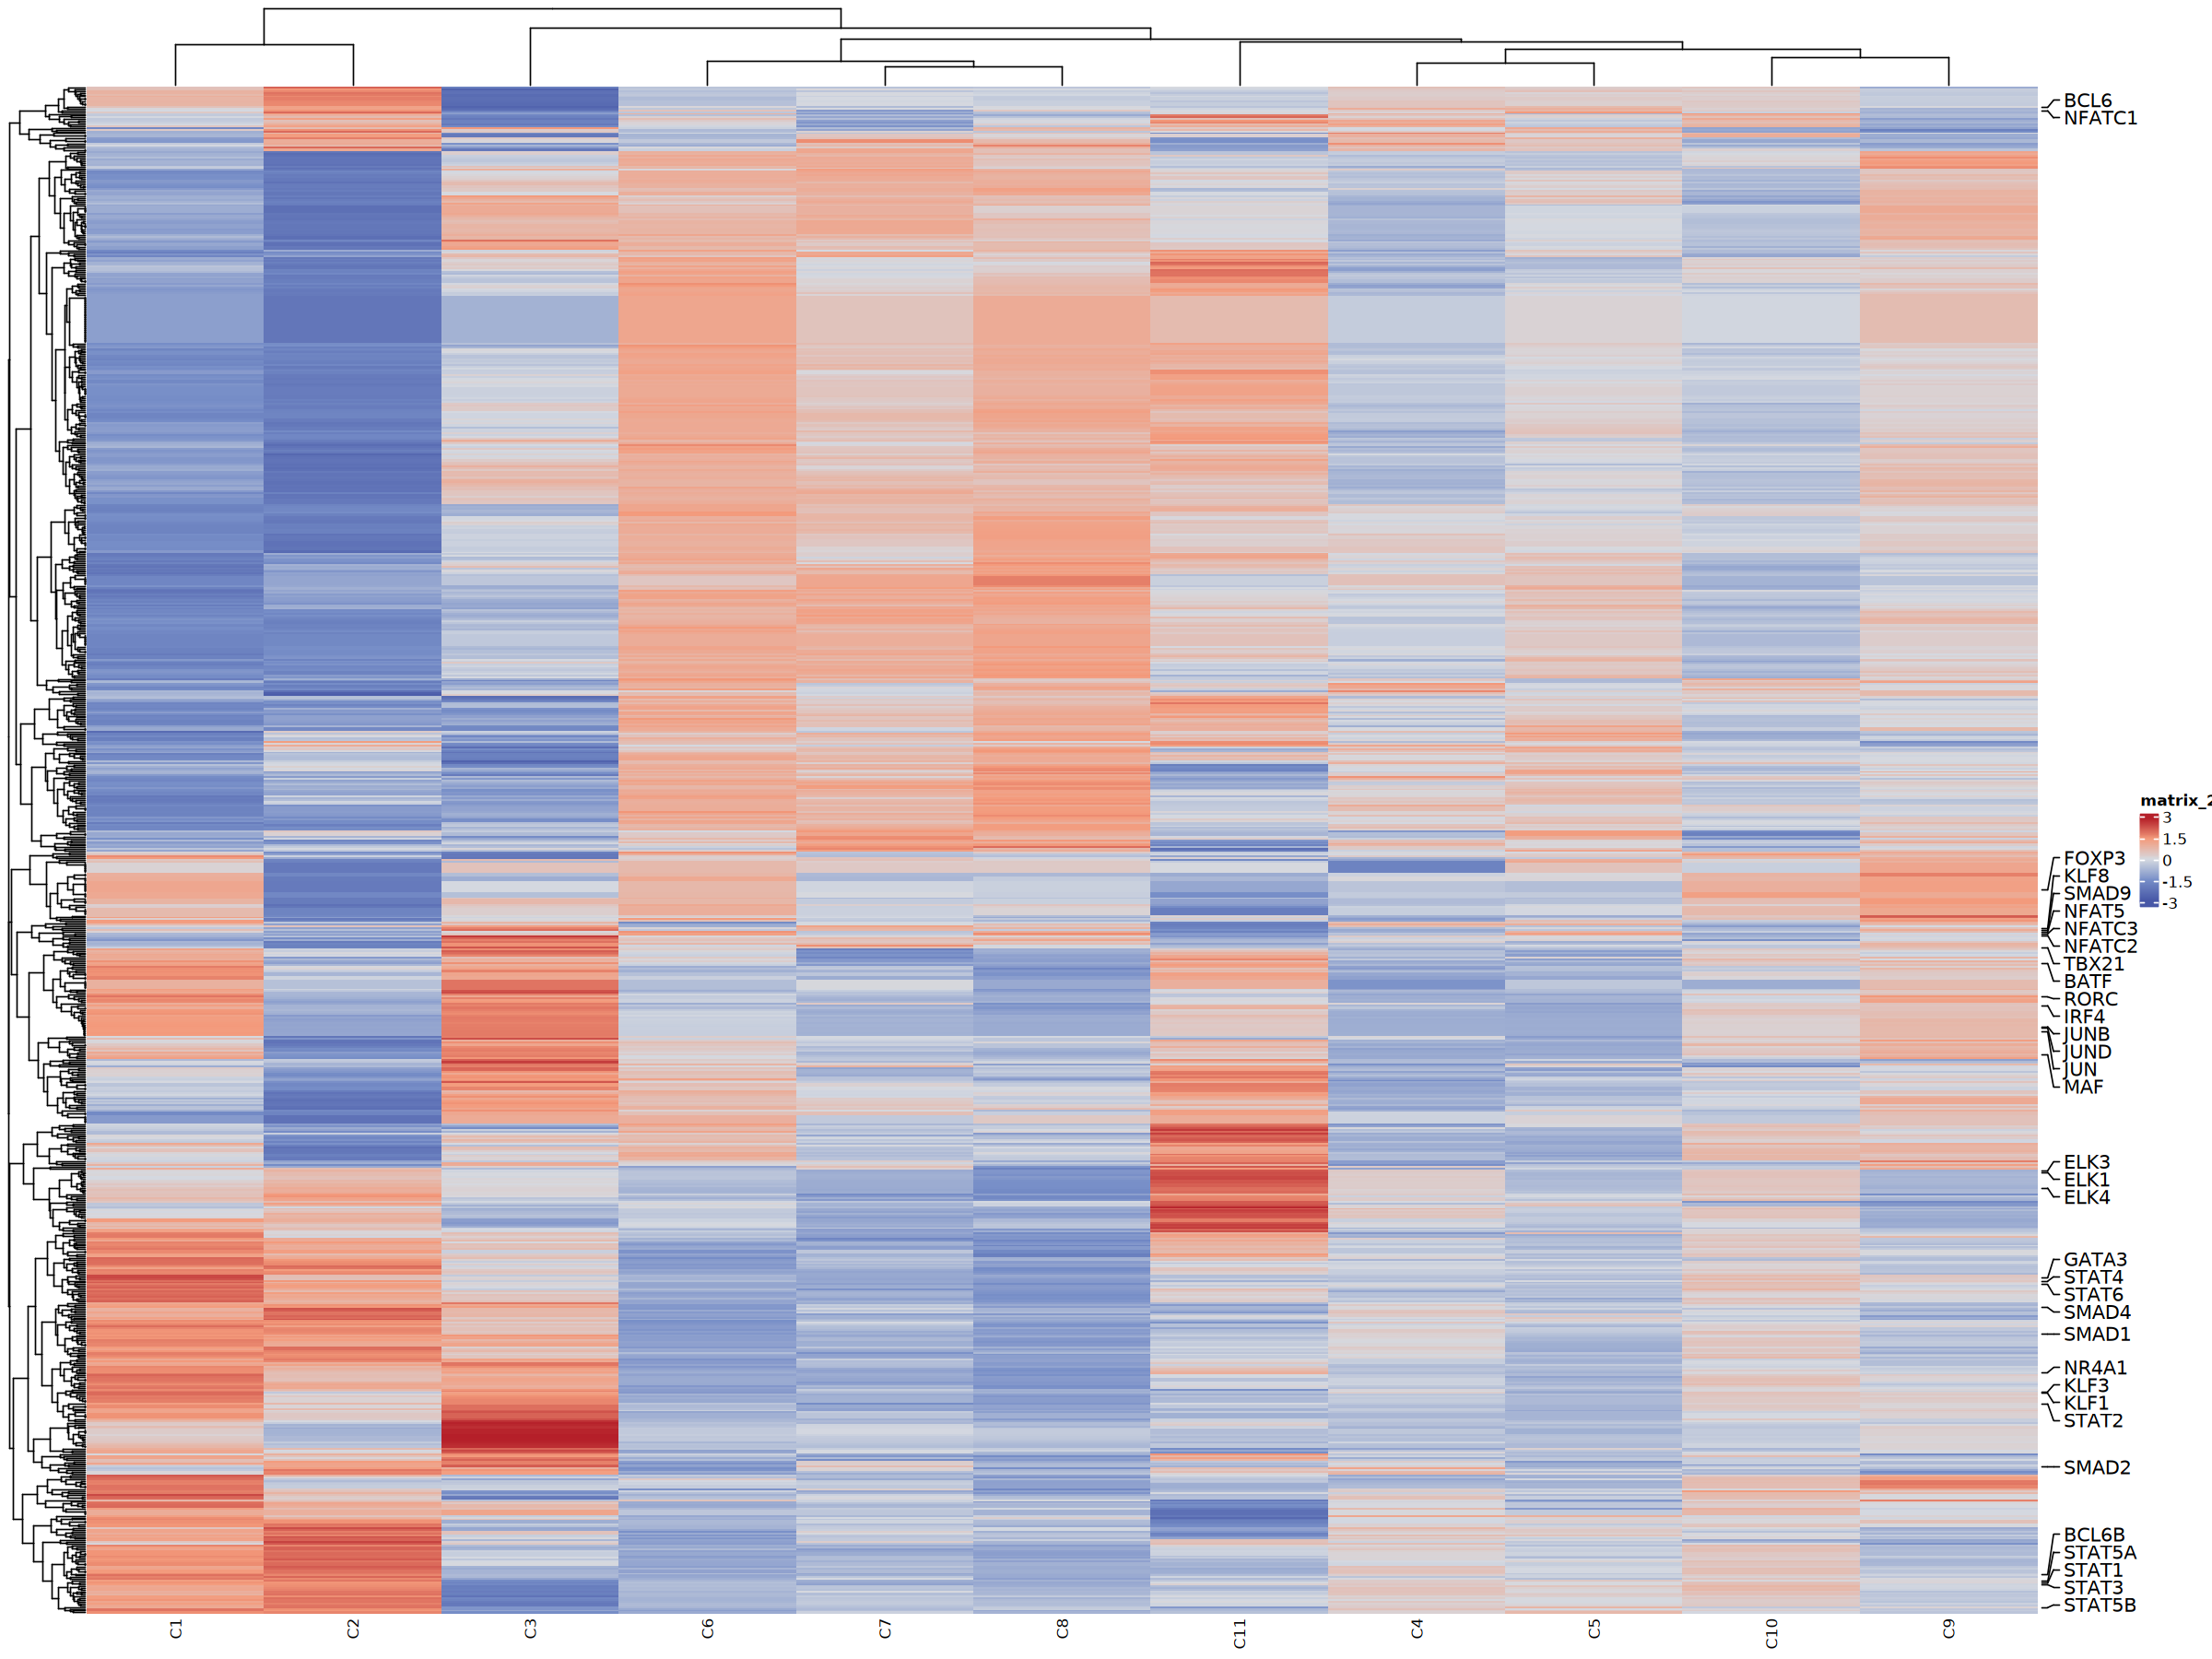

In [ ]:
print(p1)


In [ ]:
# save motif socres as a table
chromvar_motif_mean_mx <- assay(chromvar_motif_mean, "mean") %>% as_tibble(rownames = "TF")
chromvar_motif_mean_mx[1:5, 1:5]


TF,C1,C10,C11,C2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TFAP2B,0.04054568,-0.10355318,-0.12816816,0.10205882
TFAP2D,0.01783141,-0.03644647,0.16597020,0.14565063
TFAP2C,0.19278873,-0.33084516,-0.37956075,0.11659996
TFAP2E,-0.05026528,-0.12541512,-0.02854835,0.01714228
TFAP2A,0.14658593,-0.08096896,-0.07125575,0.25235843


In [ ]:
chromvar_motif_mean_mx %>% write_csv(file.path(output_path, "Teaseq_cd4t_clusters_chromvar_tf_mean_scores.csv"))


In [ ]:
output_path


[1] "/home/jupyter/data/preRA_teaseq/output_results/cd4_t/atac"

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = markersMotif,
  imputeWeights = getImputeWeights(cd4t_atac)
)


In [ ]:
motifs <- c(
    "GATA3", "SMAD4", "RORC", "FOXP3", "TBX21", "IKZF2", "NR4A1",
    "STAT3", "STAT4", "STAT5B", "STAT6", "MAF", "BCL6", "PRDM1", "SOX4"
)
# motifs <-plotVarDev %>% as_tibble() %>% distinct(name) %>% pull(name)
markerMotifs <- getFeatures(cd4t_atac, select = paste(motifs, collapse = "|"), useMatrix = "MotifMatrix")
markerMotifs
markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs


[1] "z:TBX21_780"           "z:STAT5B_779"          "z:STAT3_777"          
 [4] "z:STAT6_776"           "z:STAT4_775"           "z:SOX4_754"           
 [7] "z:SMAD4_739"           "z:RORC_681"            "z:NR4A1_671"          
[10] "z:GATA3_384"           "z:FOXP3_348"           "z:BCL6B_218"          
[13] "z:PRDM16_211"          "z:BCL6_187"            "z:PRDM1_163"          
[16] "z:MAFB_150"            "z:MAFK_149"            "z:MAFG_148"           
[19] "z:MAFF_147"            "z:MAFA_146"            "z:MAF_144"            
[22] "deviations:TBX21_780"  "deviations:STAT5B_779" "deviations:STAT3_777" 
[25] "deviations:STAT6_776"  "deviations:STAT4_775"  "deviations:SOX4_754"  
[28] "deviations:SMAD4_739"  "deviations:RORC_681"   "deviations:NR4A1_671" 
[31] "deviations:GATA3_384"  "deviations:FOXP3_348"  "deviations:BCL6B_218" 
[34] "deviations:PRDM16_211" "deviations:BCL6_187"   "deviations:PRDM1_163" 
[37] "deviations:MAFB_150"   "deviations:MAFK_149"   "deviations:MAFG_148"  
[40] "deviations:MAFF_147"   "deviations:MAFA_146"   "deviations:MAF_144"

[1] "z:TBX21_780"  "z:STAT5B_779" "z:STAT3_777"  "z:STAT6_776"  "z:STAT4_775" 
 [6] "z:SOX4_754"   "z:SMAD4_739"  "z:RORC_681"   "z:NR4A1_671"  "z:GATA3_384" 
[11] "z:FOXP3_348"  "z:BCL6B_218"  "z:PRDM16_211" "z:BCL6_187"   "z:PRDM1_163" 
[16] "z:MAFB_150"   "z:MAFK_149"   "z:MAFG_148"   "z:MAFF_147"   "z:MAFA_146"  
[21] "z:MAF_144"

### plot fig 6I


Getting ImputeWeights

Getting Matrix Values...

2024-09-12 22:58:37.015803 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5c5319277c7-Date-2024-09-12_Time-22-58-39.946717.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0153



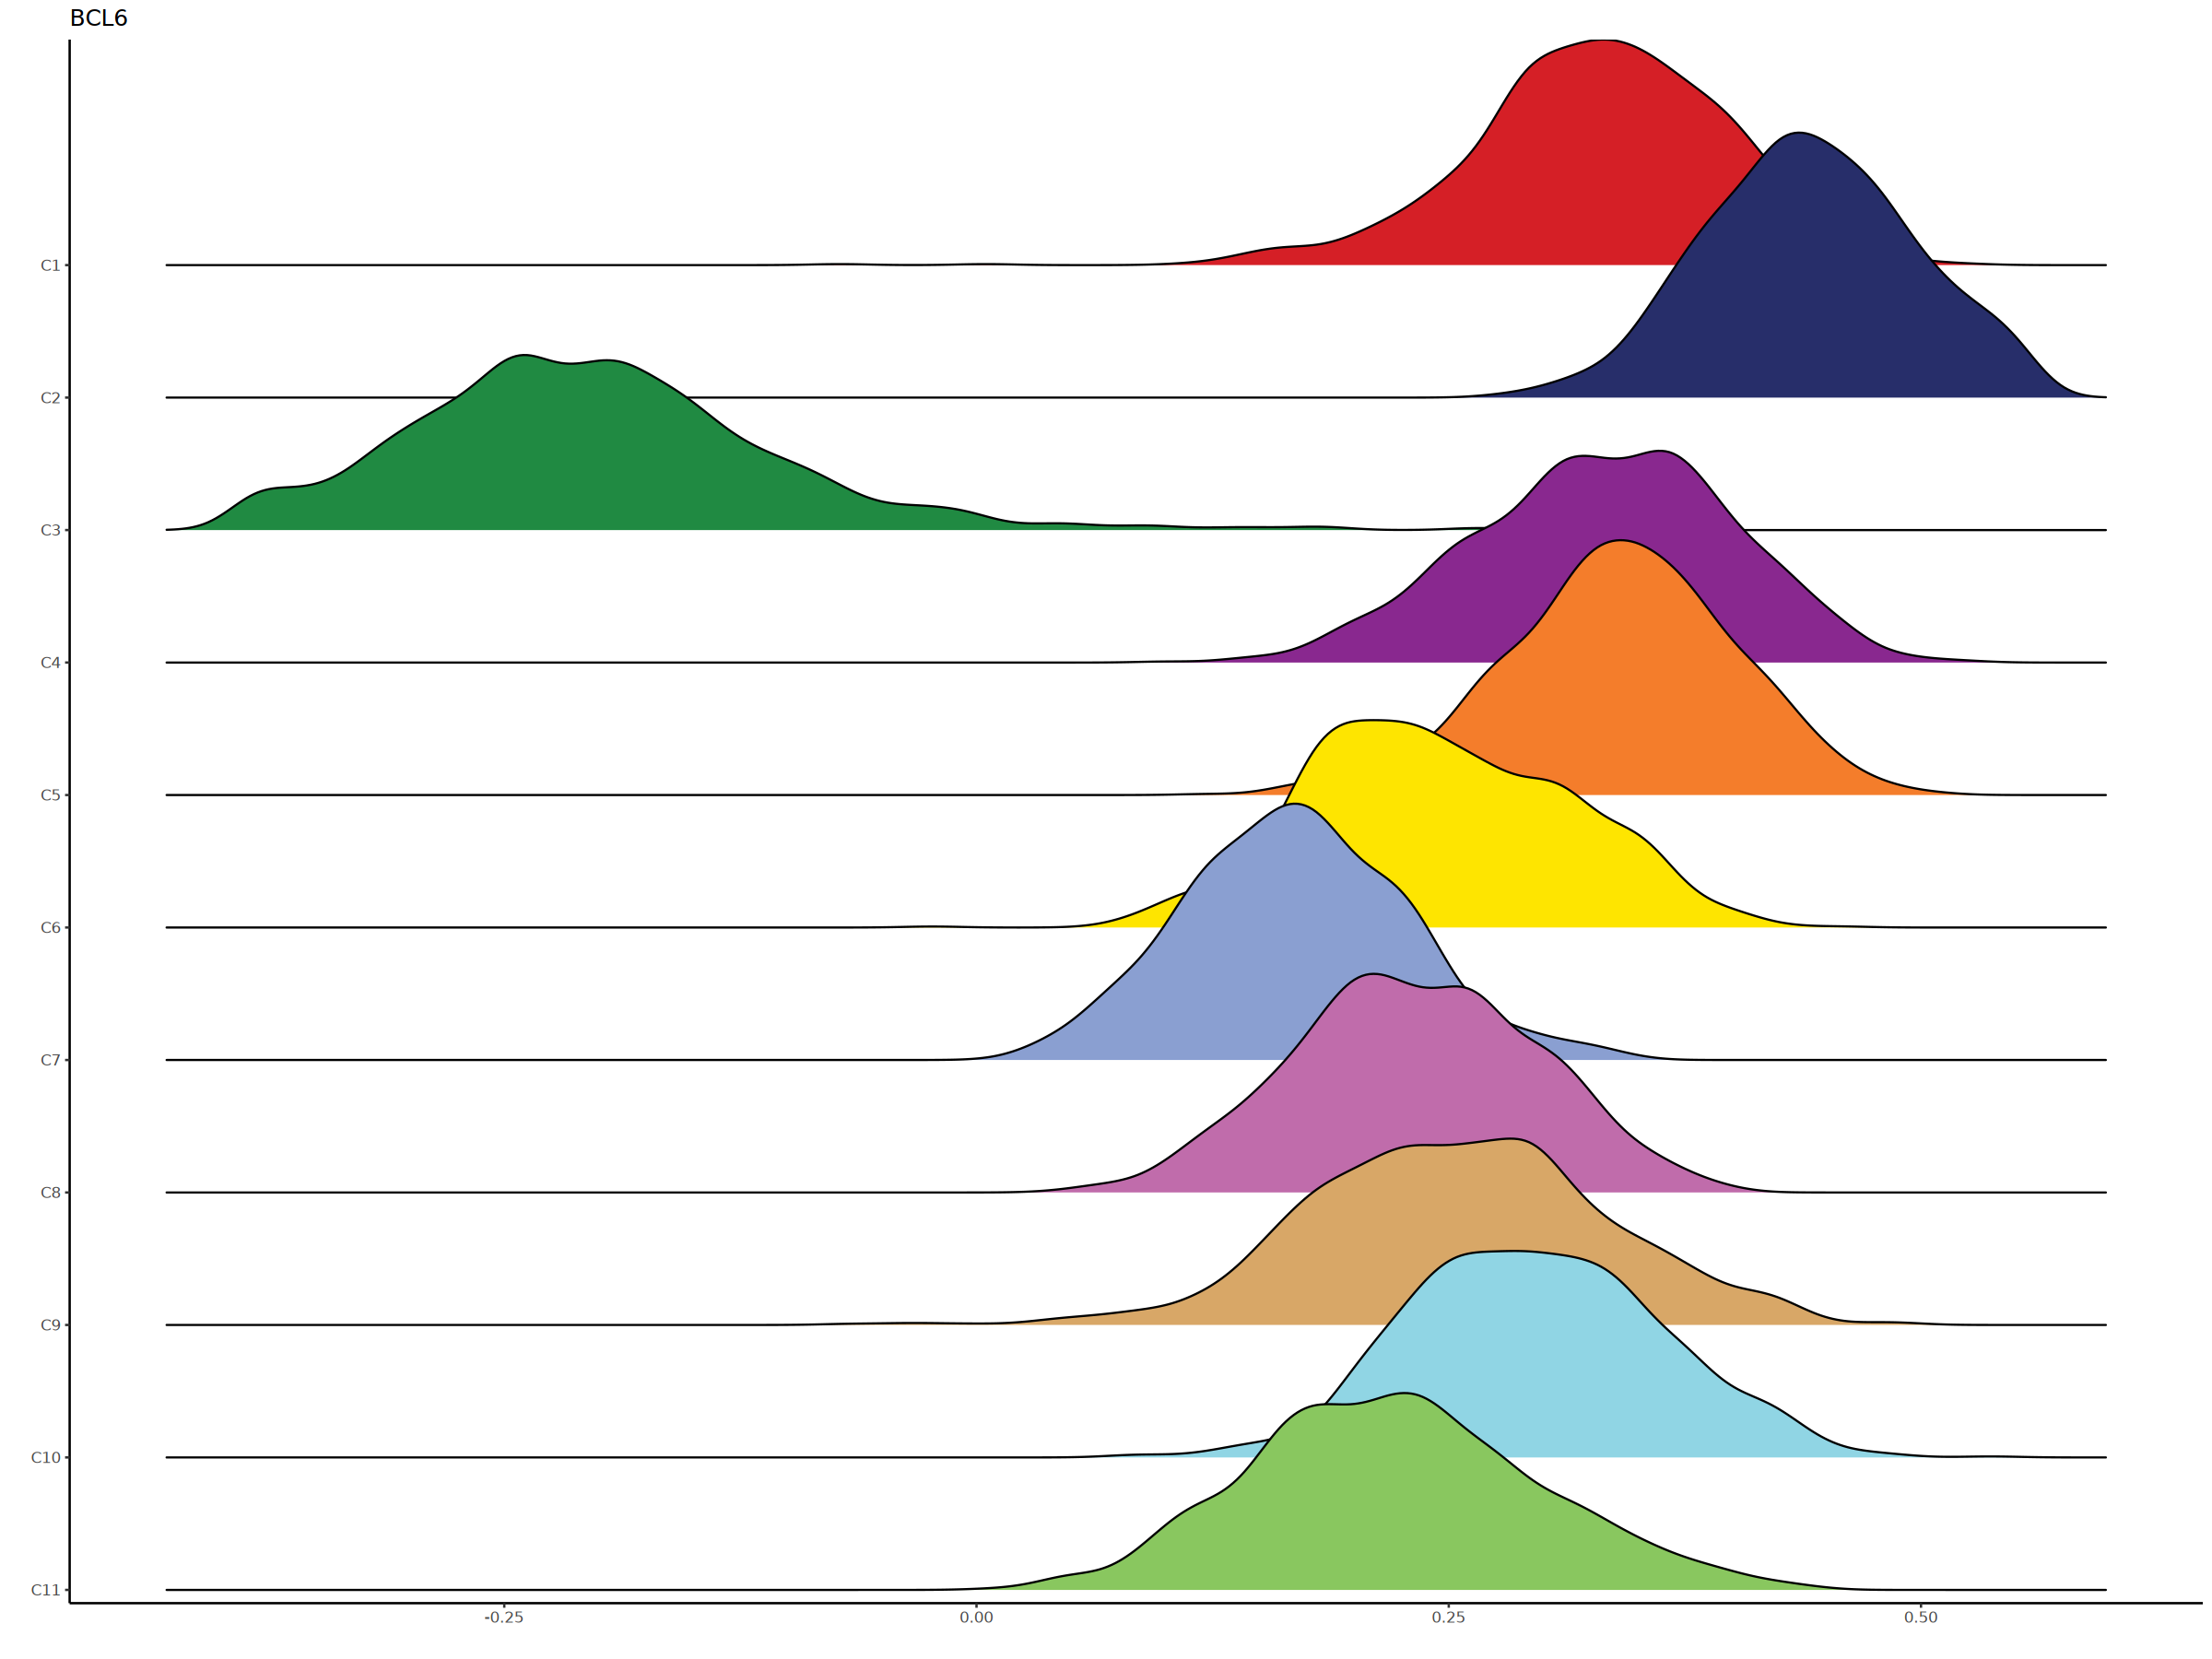

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = "z:BCL6_187"
) + xlab("") + ylab("") + ggtitle("BCL6") + ggpubr::theme_classic2()
p
# plotPDF(p, name = paste0(proj_name, '_chrovar_motif_BCL6_ridgeplot.pdf'), ArchRProj = cd4t_atac,
#         addDOC = FALSE, width = 3, height = 3)


Getting ImputeWeights

Getting Matrix Values...

2024-09-12 22:58:25.460857 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5c519995d7e-Date-2024-09-12_Time-22-58-28.380506.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0255



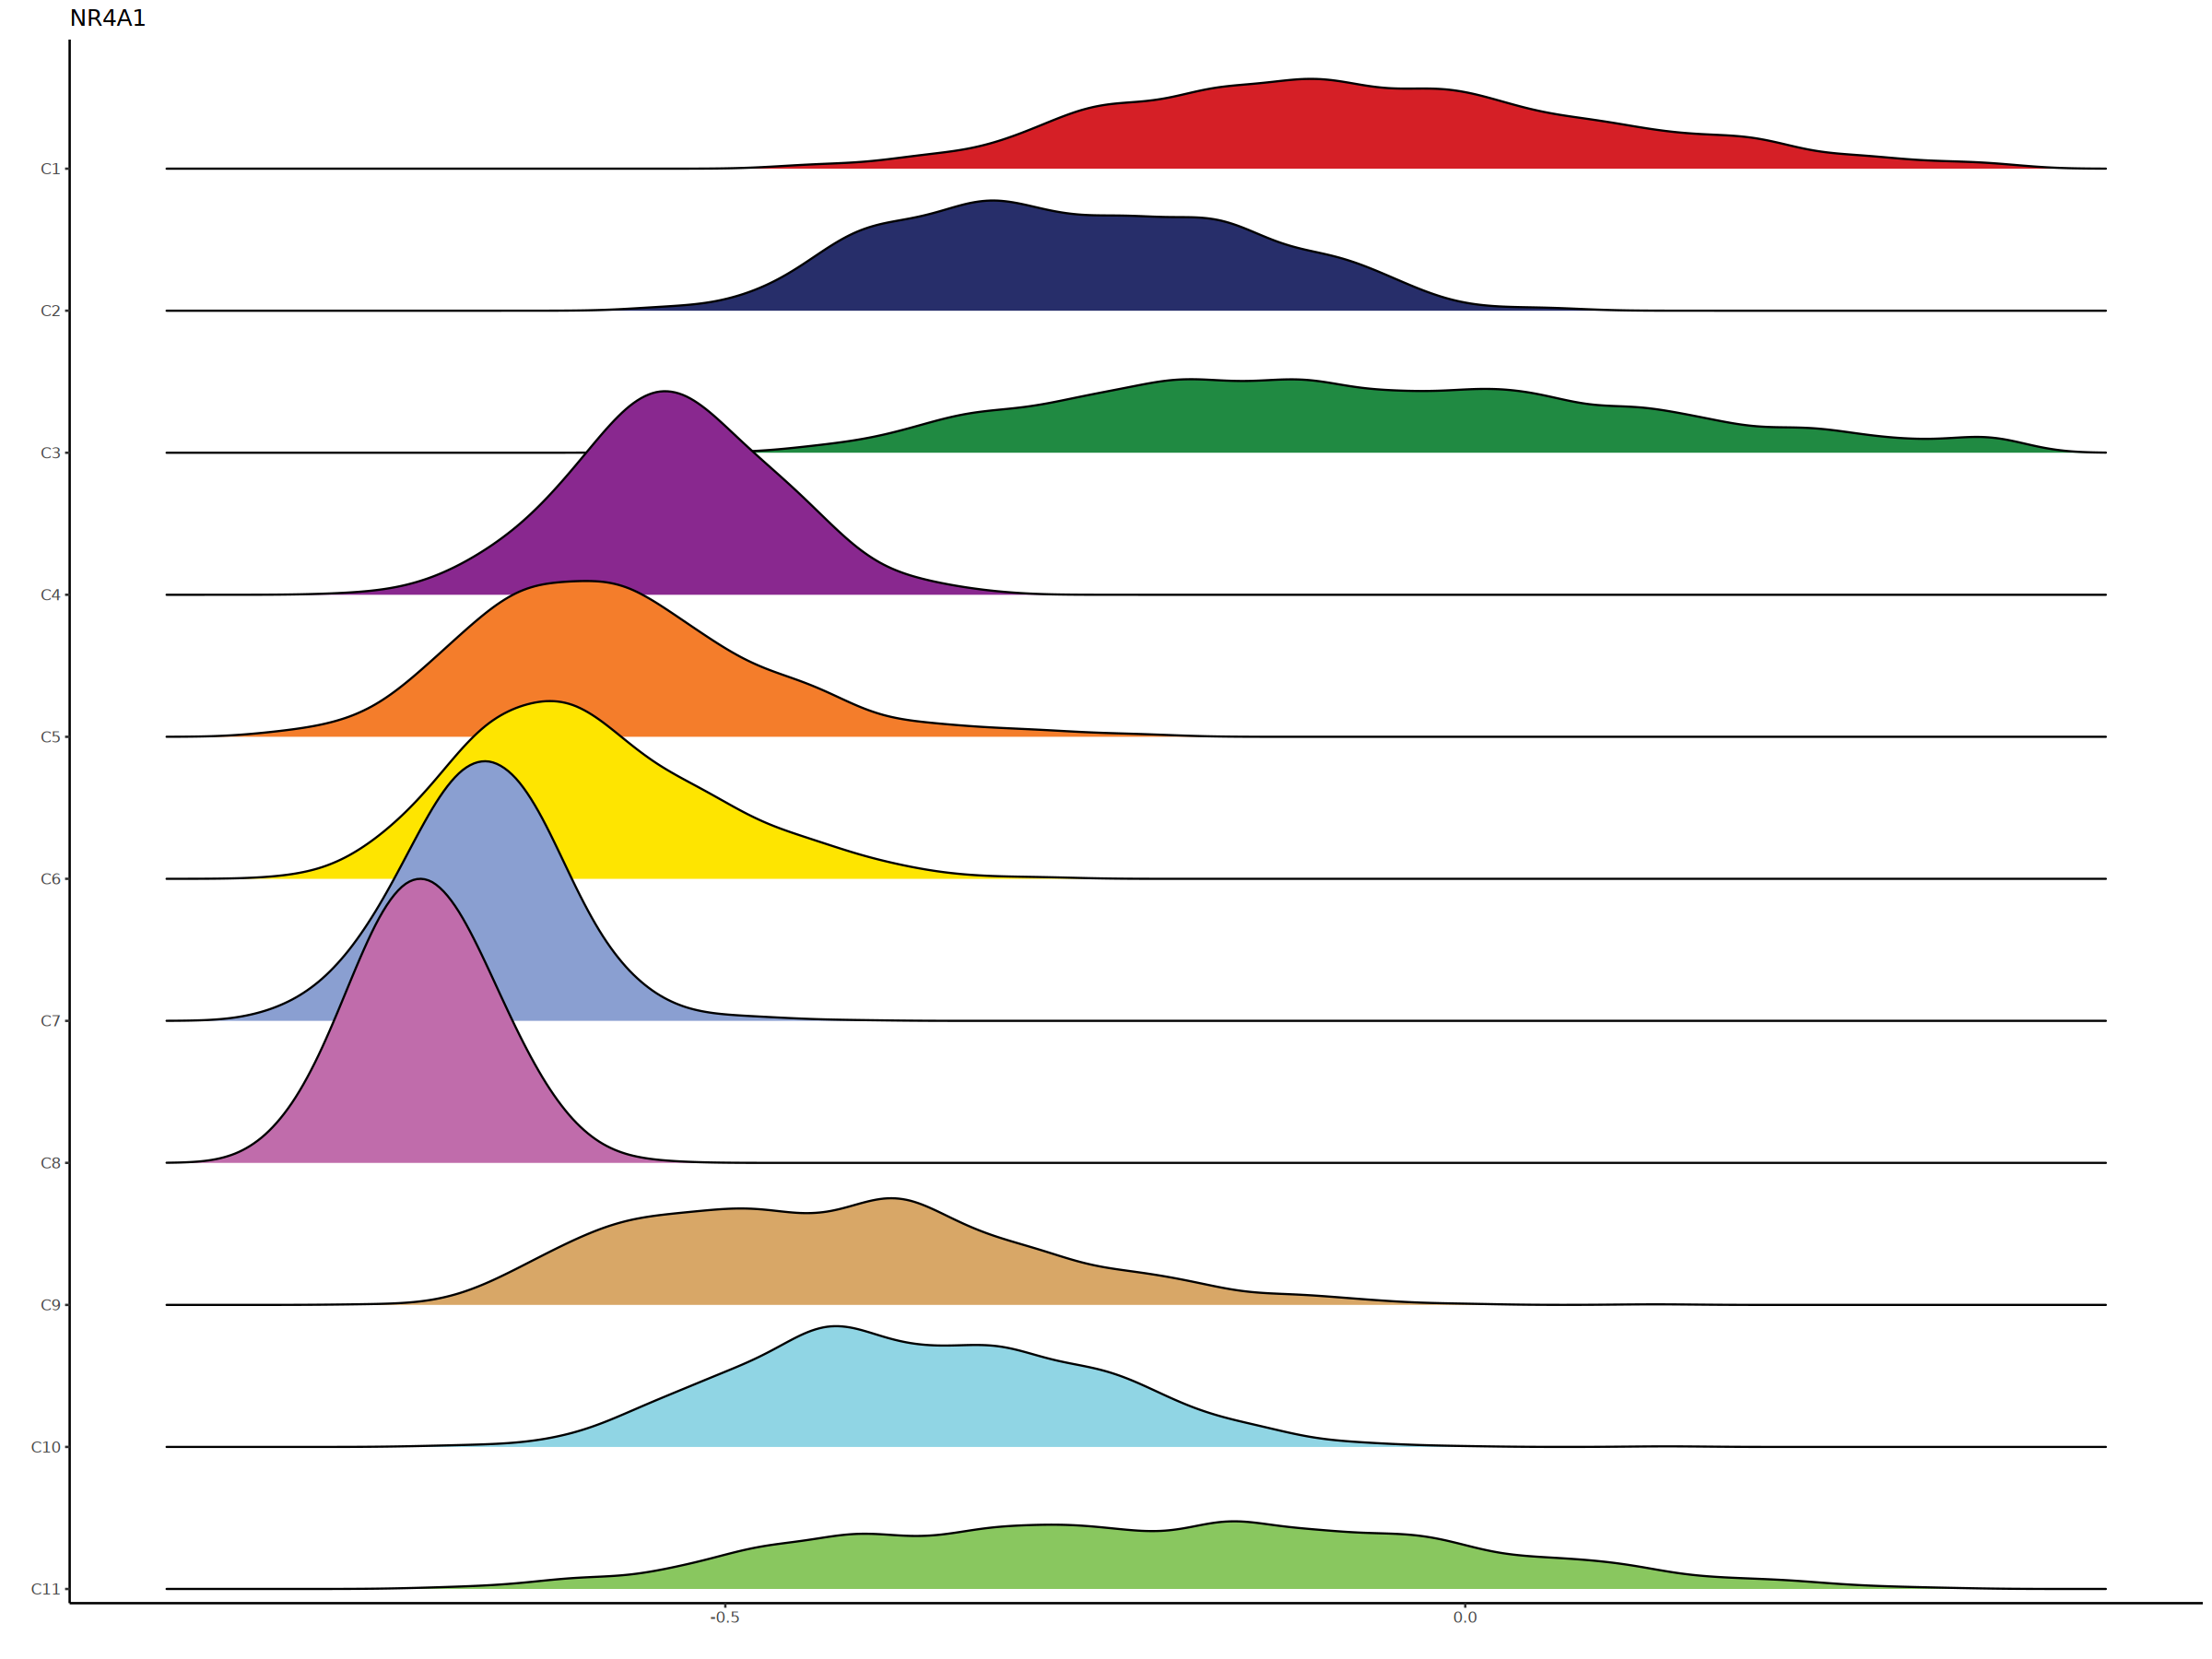

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = "z:NR4A1_671"
) + xlab("") + ylab("") + ggtitle("NR4A1") + ggpubr::theme_classic2()
p
# plotPDF(p, name = paste0(proj_name, '_chrovar_motif_BNR4A1_ridgeplot.pdf'), ArchRProj = cd4t_atac,
#         addDOC = FALSE, width = 3, height = 3)


In [ ]:
getAvailableMatrices(cd4t_atac)


[1] "GeneExpressionMatrix" "GeneScoreMatrix"      "MochaPeakMatrix"     
[4] "MotifMatrix"          "PeakMatrix"           "TileMatrix"          
[7] "TransferMatrix"       "TransferPeakMatrix"

Getting Matrix Values...

2024-08-15 18:13:23 : 



1 




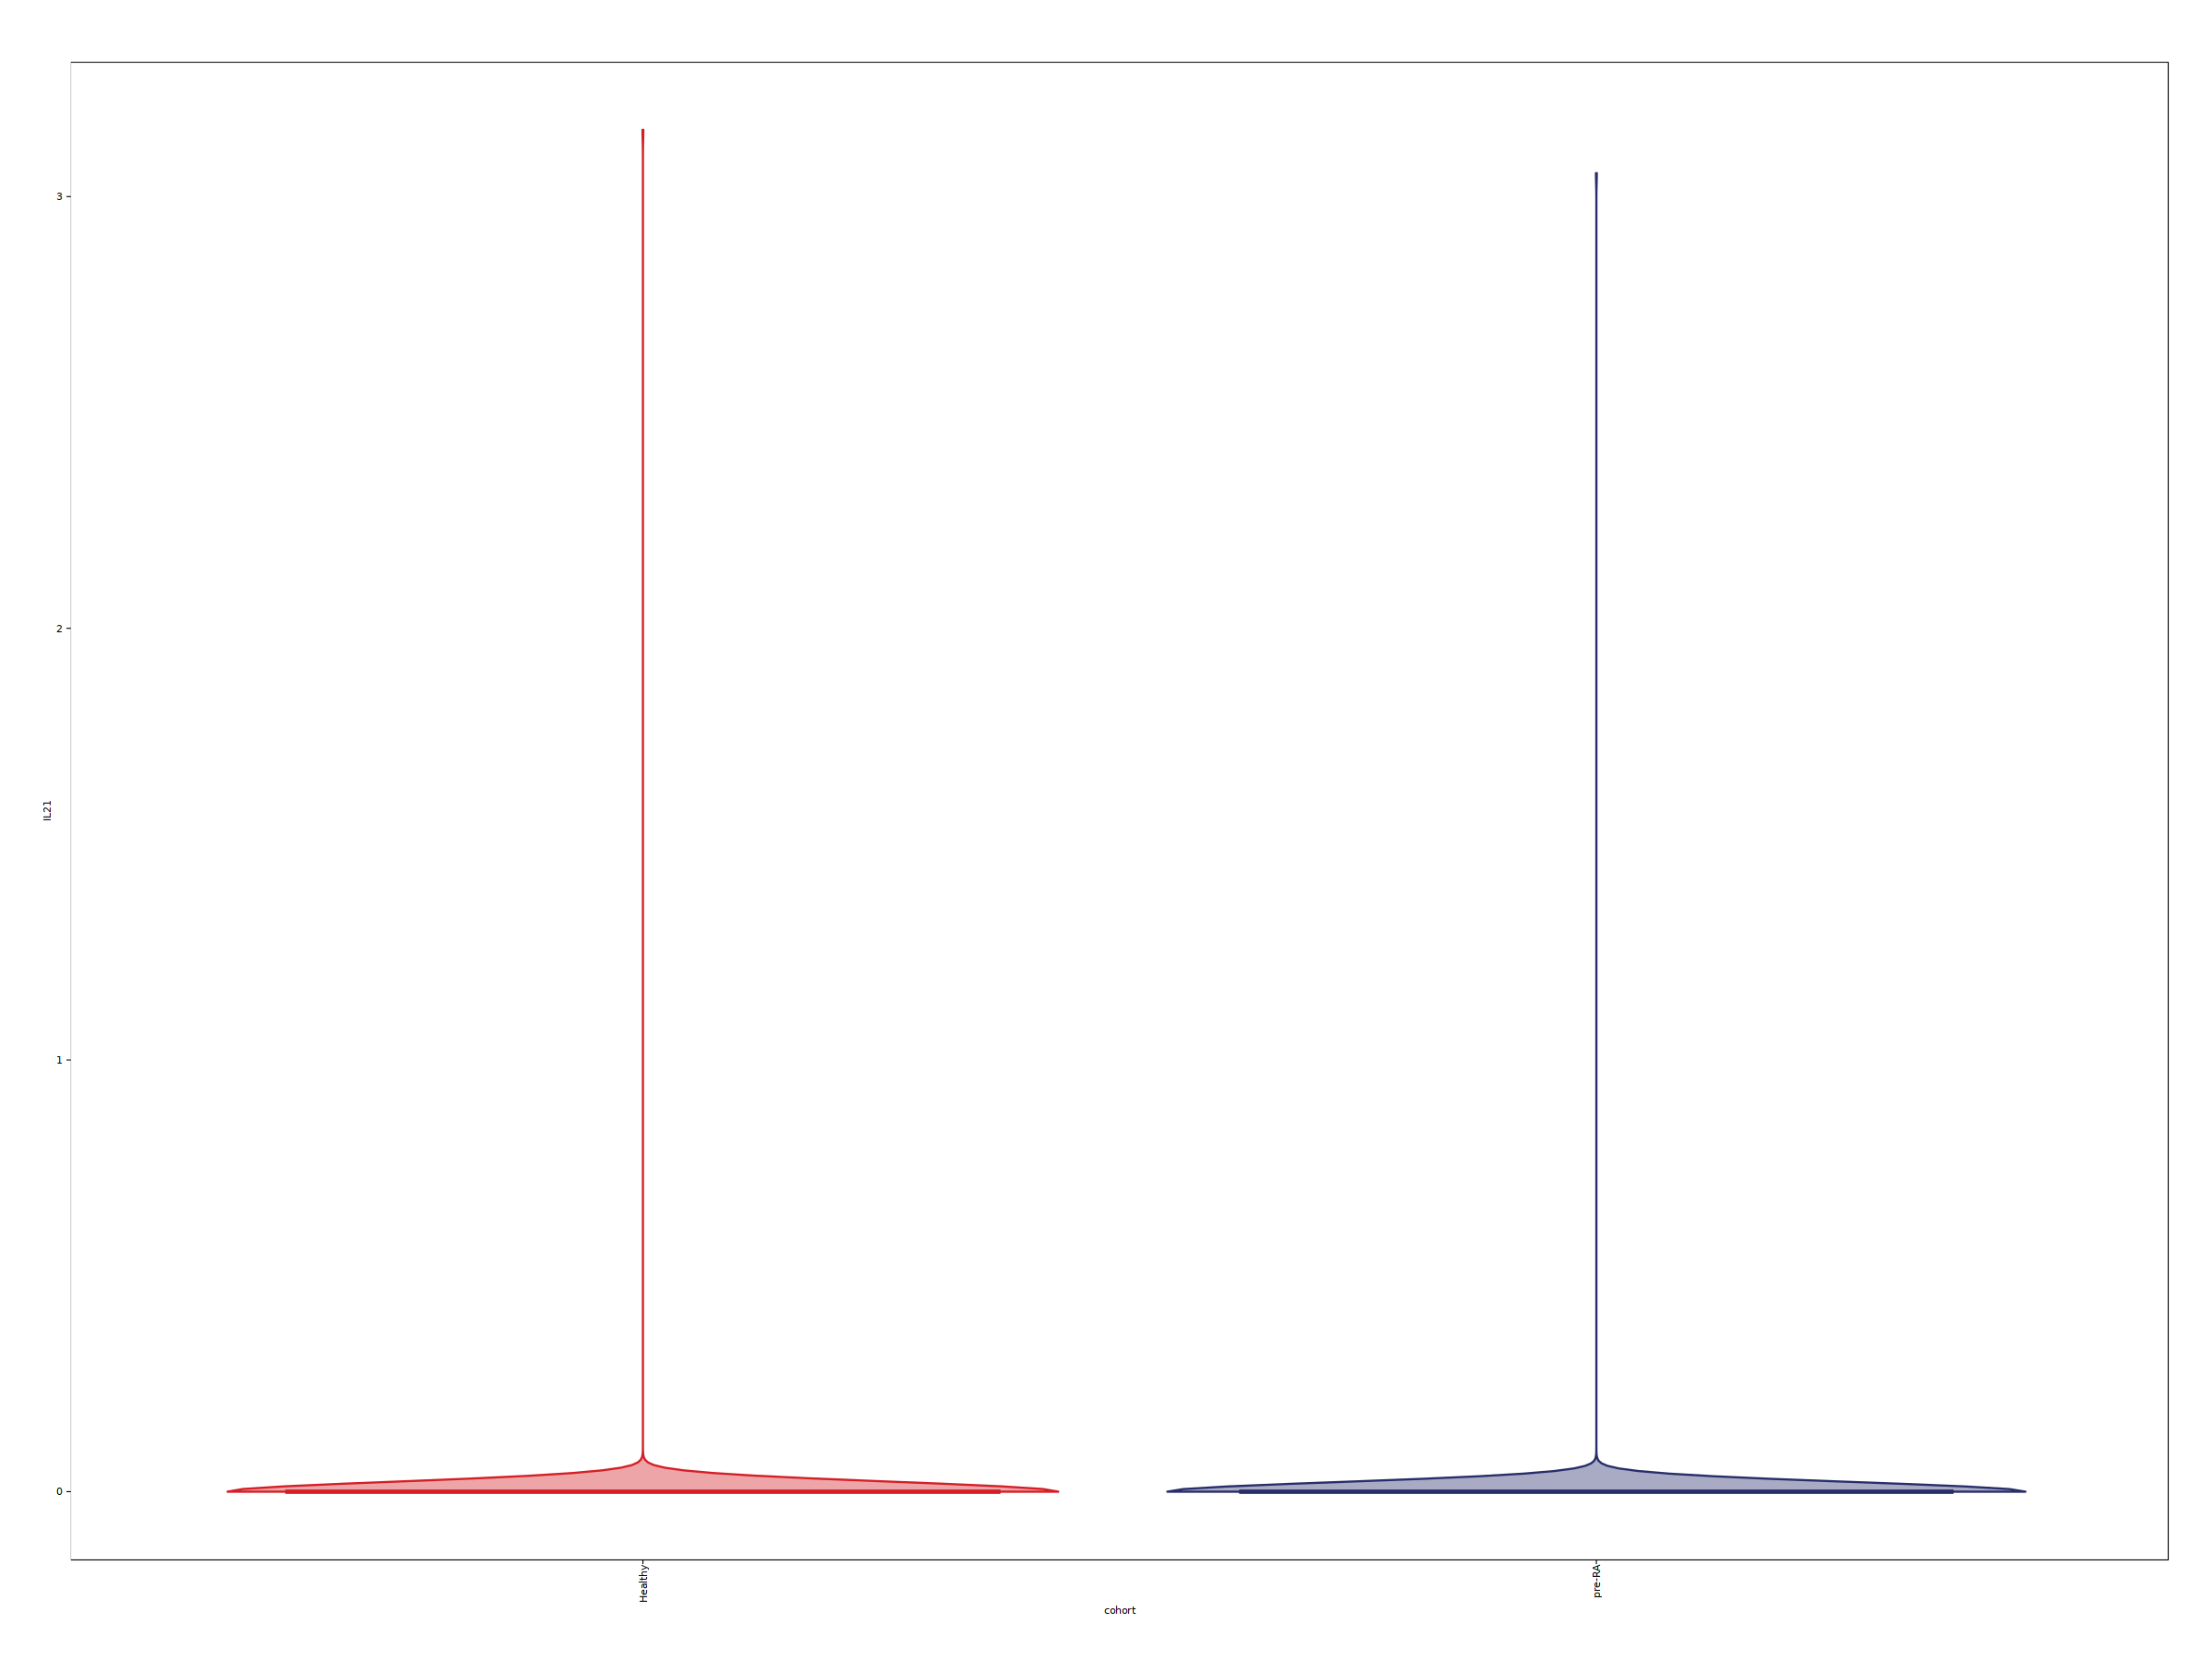

In [ ]:
p2 <- plotGroups(
    ArchRProj = cd4t_atac,
    groupBy = "cohort",
    colorBy = "GeneExpressionMatrix",
    name = "IL21",
    plotAs = "violin",
    alpha = 0.4,
    addBoxPlot = TRUE,
    imputeWeights = NULL
)
p2


In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0_8",
  colorBy = "MotifMatrix",
  name = "z:BCL6_187"
) + xlab("") + ylab("") + ggtitle("BCL6") + ggpubr::theme_classic2()
p
plotPDF(p,
  name = paste0(proj_name, "_chrovar_motif_BCL6_ridgeplot.pdf"), ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 3, height = 3
)


Getting ImputeWeights

Getting Matrix Values...

2024-08-15 17:50:57 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5cf64117b40-Date-2024-08-15_Time-17-50-59.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0235

Plotting Ggplot!

Picking joint bandwidth of 0.0235

Picking joint bandwidth of 0.0235



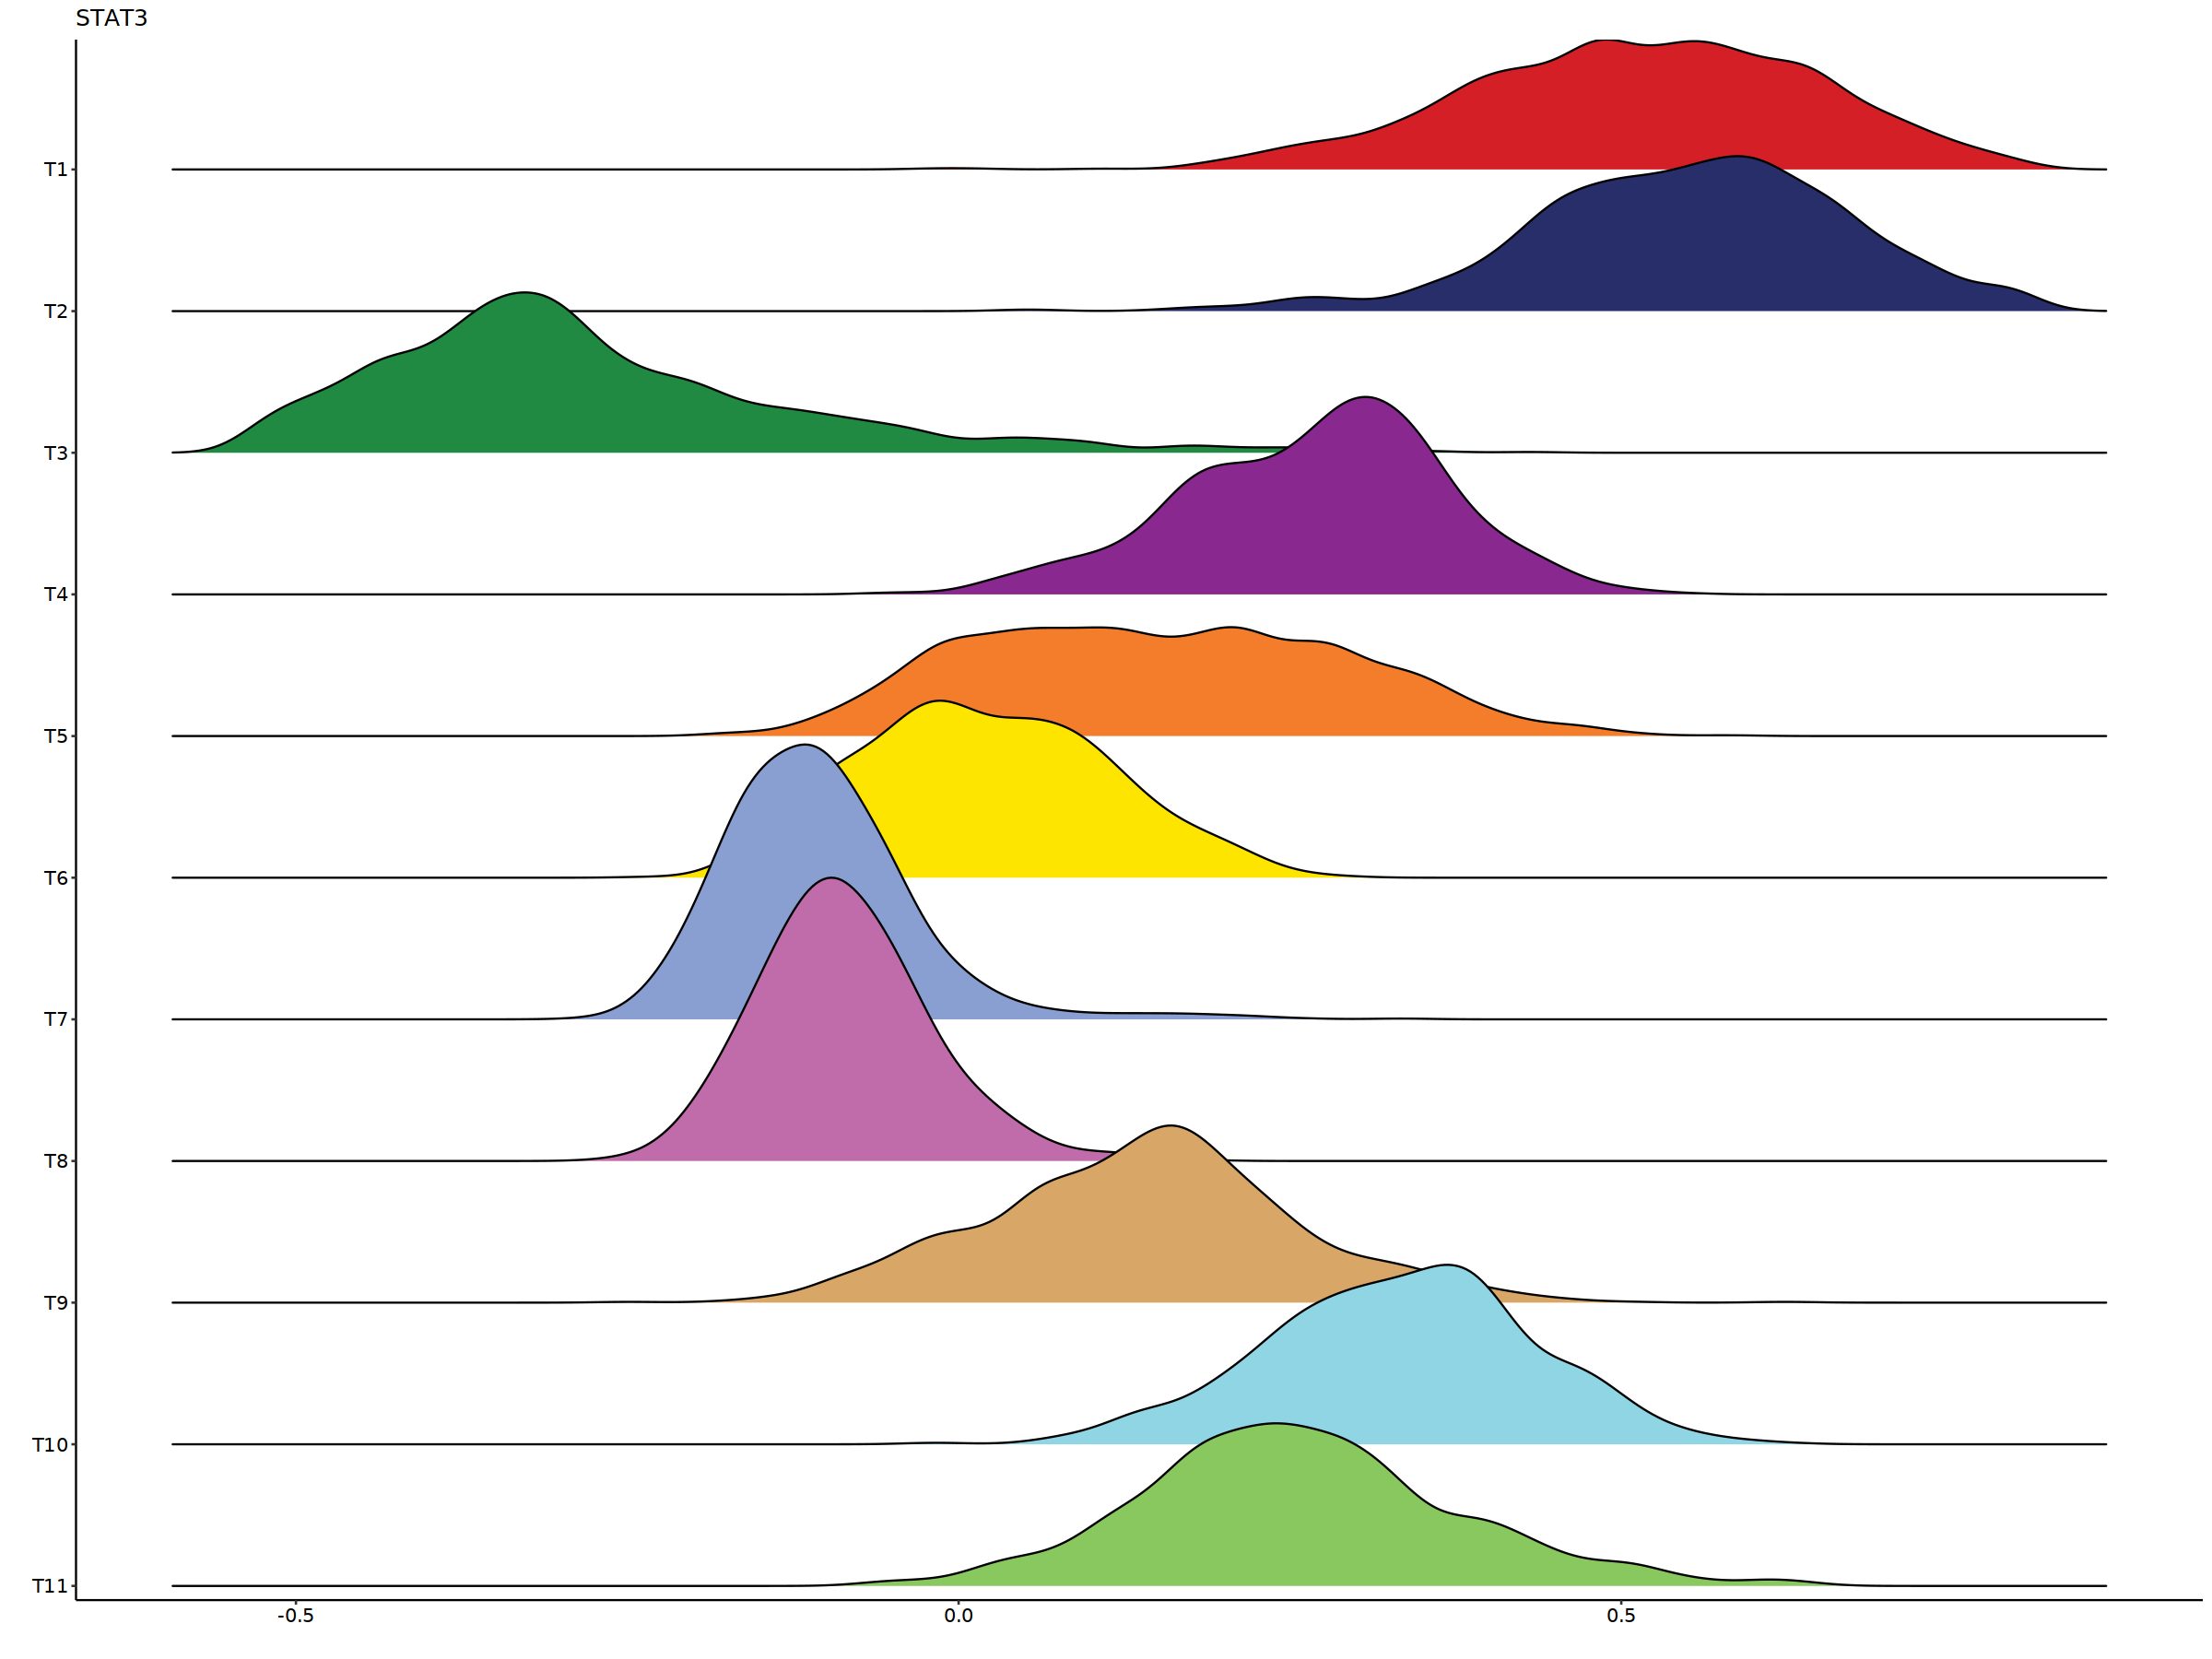

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0_8",
  colorBy = "MotifMatrix",
  name = "z:STAT3_777"
) + xlab("") + ylab("") + ggtitle("STAT3") + ggpubr::theme_pubr()
p
plotPDF(p,
  name = paste0(proj_name, "_chrovar_motif_STAT3_ridgeplot.pdf"), ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 3, height = 3
)


Getting ImputeWeights

Getting Matrix Values...

2024-07-25 22:17:05 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-12191fe61065-Date-2024-07-25_Time-22-17-11.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0375

Plotting Ggplot!

Picking joint bandwidth of 0.0375

Picking joint bandwidth of 0.0375



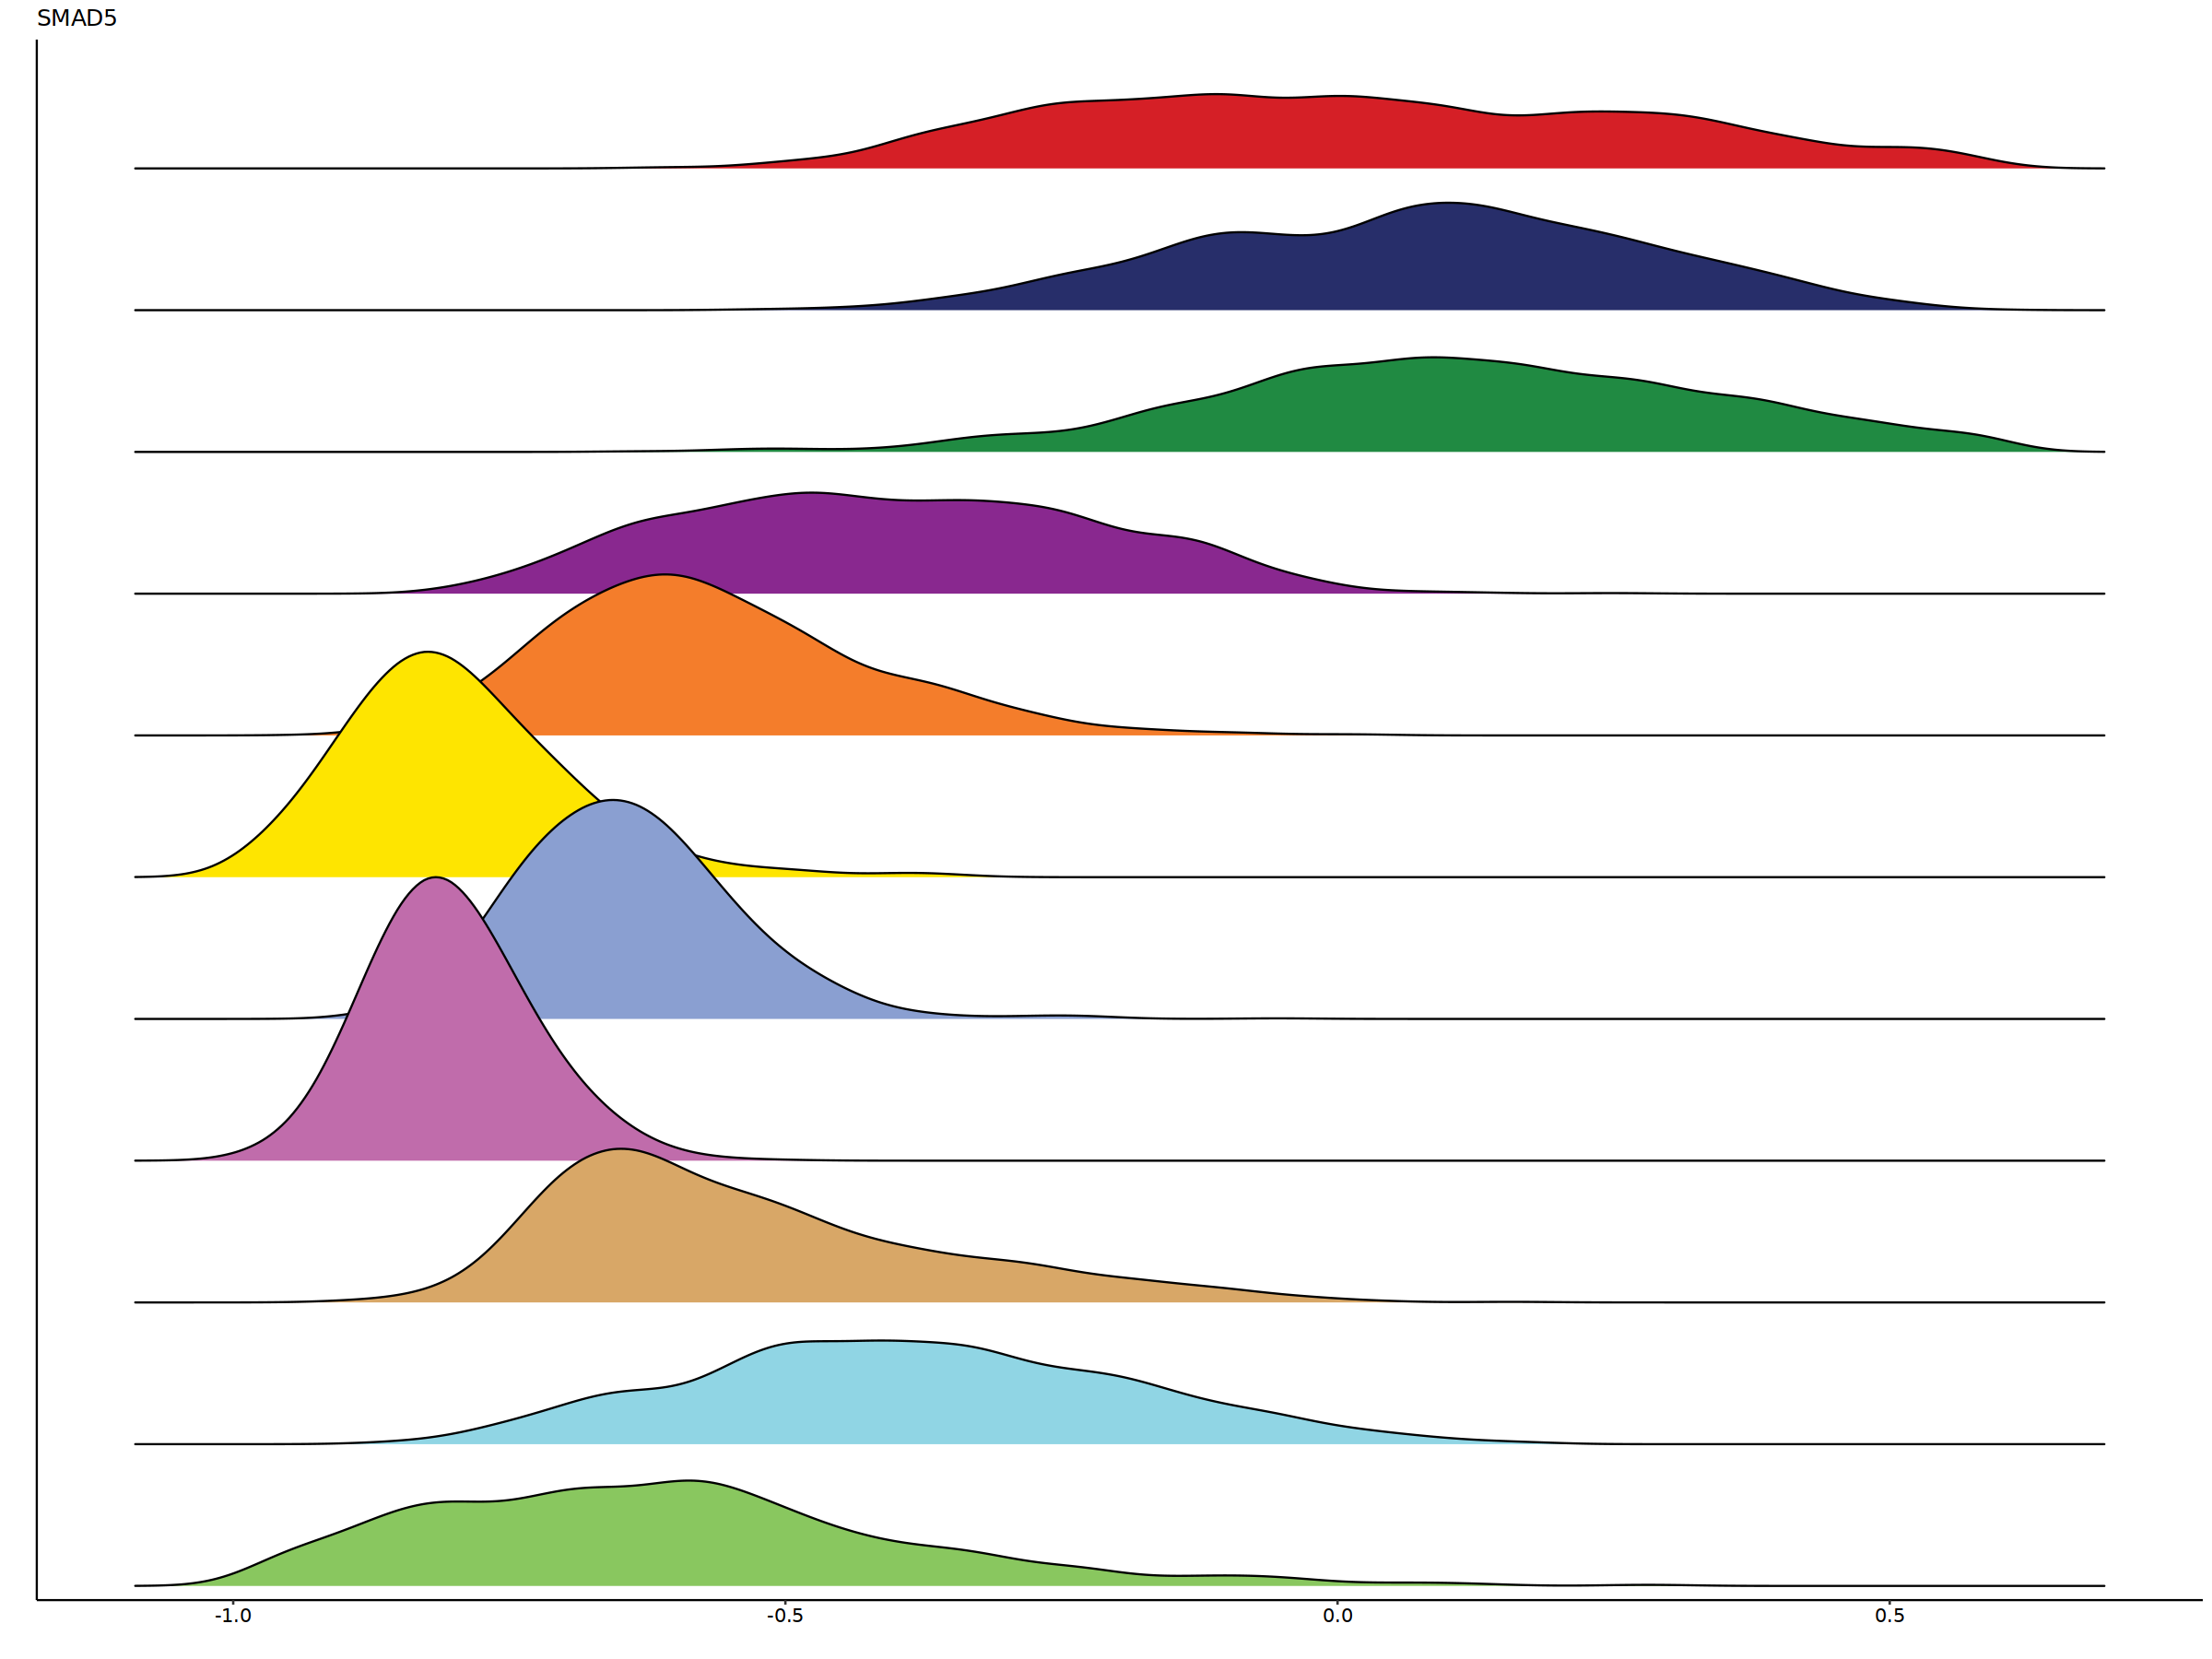

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = "z:SMAD4_739"
) + xlab("") + ylab("") + ggtitle("SMAD4") + ggpubr::theme_pubr() +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank()
  )
p
plotPDF(p,
  name = paste0(proj_name, "_chrovar_motif_SMAD4_ridgeplot.pdf"), ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 4, height = 4
)


In [ ]:
p2 <- plotGroups(
    ArchRProj = cd4t_atac,
    groupBy = "Clusters_0.8",
    colorBy = "MotifMatrix",
    name = c("z:BCL6_187", "z:SOX4_754", "z:RORC_681", "z:MAF_144"),
    plotAs = "violin",
    alpha = 0.6,
    addBoxPlot = TRUE
)
p2
plotPDF(p2,
    name = paste0(proj_name, "_atac_umap_chrovar_motif_box_plot.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 4, height = 4
)


In [ ]:
p2 <- plotGroups(
    ArchRProj = cd4t_atac,
    groupBy = "Clusters_0.8",
    colorBy = "MotifMatrix",
    name = c("z:BCL6_187", "z:SOX4_754", "z:RORC_681", "z:MAF_144"),
    plotAs = "violin",
    alpha = 0.6,
    addBoxPlot = TRUE
)
p2
plotPDF(p2,
    name = paste0(proj_name, "_atac_umap_chrovar_motif_box_plot.pdf"), ArchRProj = cd4t_atac,
    addDOC = FALSE, width = 4, height = 4
)


In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  maxCells = 1500,
  name = c("z:SOX4_754", "z:BCL6_187", "z:PRDM1_163", "z:RORC_681"),
  imputeWeights = getImputeWeights(cd4t_atac)
)
p
plotPDF(p,
  name = paste0(proj_name, "_atac_umap_chrovar_motif_bridge_plot.pdf"), ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 6, height = 6
)


In [ ]:
# p2 <- lapply(seq_along(p), function(x){
#   if(x != 1){
#     p[[x]] + guides(color = FALSE, fill = FALSE) +
#     theme_ArchR(baseSize = 6) +
#     theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
#     theme(
#         axis.text.y=element_blank(),
#         axis.ticks.y=element_blank(),
#         axis.title.y=element_blank()
#     ) + ylab("")
#   }else{
#     p[[x]] + guides(color = FALSE, fill = FALSE) +
#     theme_ArchR(baseSize = 6) +
#     theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
#     theme(
#         axis.ticks.y=element_blank(),
#         axis.title.y=element_blank()
#     ) + ylab("")
#   }
# })
# do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2, rep(1, length(p2) - 1))),p2))
# ggsave(file.path(fig_path, paste0(proj_name, '_atac_umap_chrovar_motif_bridge_plot.pdf')), width = 5, height = 5)


## add Trajectory of the clusters


In [ ]:
cd4t_atac$Clusters_0.8 %>% unique()


[1] "C1"  "C2"  "C10" "C4"  "C3"  "C9"  "C11" "C5"  "C7"  "C8"  "C6"

In [ ]:
trajectory <- c("C2", "C1")


In [ ]:
cd4t_atac <- addTrajectory(
    ArchRProj = cd4t_atac,
    name = "CD4TnaC2toC1",
    groupBy = "Clusters_0.8",
    trajectory = trajectory,
    # reducedDims = "UMAP",
    embedding = "UMAP",
    force = TRUE
)


ArchR logging to : ArchRLogs/ArchR-addTrajectory-9fe69477fa9-Date-2024-07-24_Time-20-38-09.log
If there is an issue, please report to github with logFile!

Filtering outliers

Initial Alignment Before Spline Fit

Spline Fit

KNN to Spline

Overriding previous entry for CD4TnaC2toC1

ArchR logging successful to : ArchRLogs/ArchR-addTrajectory-9fe69477fa9-Date-2024-07-24_Time-20-38-09.log



In [ ]:
# # add monocle trajectory
# cd4t_atac <- getMonocleTrajectories(
#     ArchRProj = cd4t_atac,
#     name = "CD4TnaMonocle",
#     useGroups = cd4t_atac$Clusters_0.8,
#     groupBy = "Clusters_0.8",
#     principalGroup = 'C2',
#     embedding = "UMAP"
# )


In [ ]:
saveArchRProject(cd4t_atac)


In [ ]:
p <- plotTrajectory(cd4t_atac, trajectory = "CD4TnaC2toC1", colorBy = "cellColData", name = "CD4TnaC2toC1")


ArchR logging to : ArchRLogs/ArchR-plotTrajectory-9fe31978629-Date-2024-07-24_Time-20-38-13.log
If there is an issue, please report to github with logFile!

Plotting

Warning message:
“Removed 39562 rows containing non-finite values (`stat_summary_hex()`).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-9fe31978629-Date-2024-07-24_Time-20-38-13.log



Warning message:
“Removed 39562 rows containing non-finite values (`stat_summary_hex()`).”


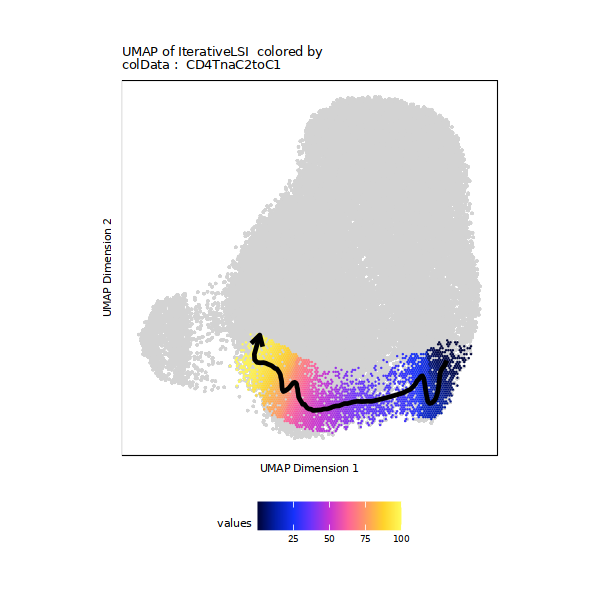

In [ ]:
p[[1]]


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


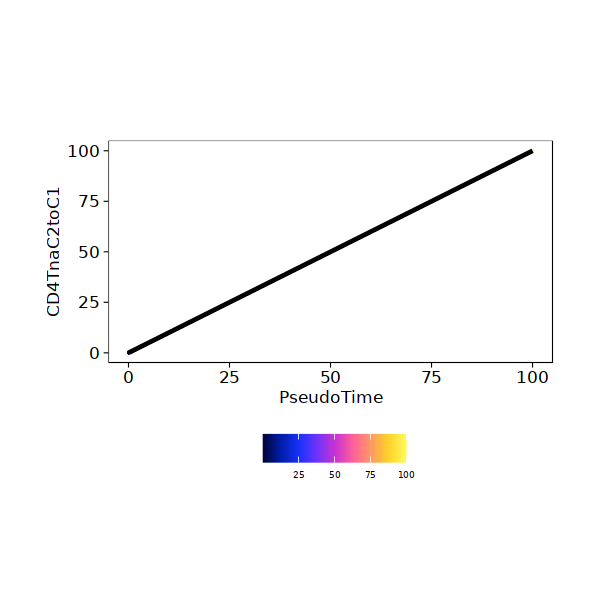

In [ ]:
p[[2]]


In [ ]:
getAvailableMatrices(cd4t_atac)


[1] "GeneExpressionMatrix" "GeneScoreMatrix"      "MochaPeakMatrix"     
[4] "MotifMatrix"          "PeakMatrix"           "TileMatrix"          
[7] "TransferMatrix"       "TransferPeakMatrix"

In [ ]:
trajMM <- getTrajectory(
    ArchRProj = cd4t_atac, name = "CD4TnaC2toC1", scaleTo = NULL,
    useMatrix = "MotifMatrix", log2Norm = FALSE
)


Creating Trajectory Group Matrix..

Smoothing...



In [ ]:
trajMM


class: SummarizedExperiment 
dim: 1740 100 
metadata(1): Params
assays(2): smoothMat mat
rownames(1740): deviations:TFAP2B_1 deviations:TFAP2D_2 ... z:TBX18_869
  z:TBX22_870
rowData names(3): seqnames idx name
colnames(100): T.0_1 T.1_2 ... T.98_99 T.99_100
colData names(0):

In [ ]:
# p2 <- plotTrajectory(cd4t_atac, trajectory = "CD4TnaC2toC1",
#                      colorBy = "GeneScoreMatrix", name = "IL21", continuousSet = "blueYellow")


In [ ]:
# p2[[1]]


In [ ]:
# only keep the z score
trajMM_z <- trajMM[str_detect(rownames(trajMM), "z:"), ]
trajMM_z


class: SummarizedExperiment 
dim: 870 100 
metadata(1): Params
assays(2): smoothMat mat
rownames(870): z:TFAP2B_1 z:TFAP2D_2 ... z:TBX18_869 z:TBX22_870
rowData names(3): seqnames idx name
colnames(100): T.0_1 T.1_2 ... T.98_99 T.99_100
colData names(0):

In [ ]:
p1 <- plotTrajectoryHeatmap(trajMM,
    labelRows = TRUE, returnMatrix = FALSE,
    pal = paletteContinuous(set = "solarExtra")
)


ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe74ff38db-Date-2024-07-24_Time-21-08-14.log
If there is an issue, please report to github with logFile!

useSeqnames is NULL or greater than 1 with a Sparse.Assays.Matrix trajectory input.

2024-07-24 21:08:15 : 

force=FALSE thus continuing with subsetting useSeqnames = z

2024-07-24 21:08:15 : 

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe74ff38db-Date-2024-07-24_Time-21-08-14.log



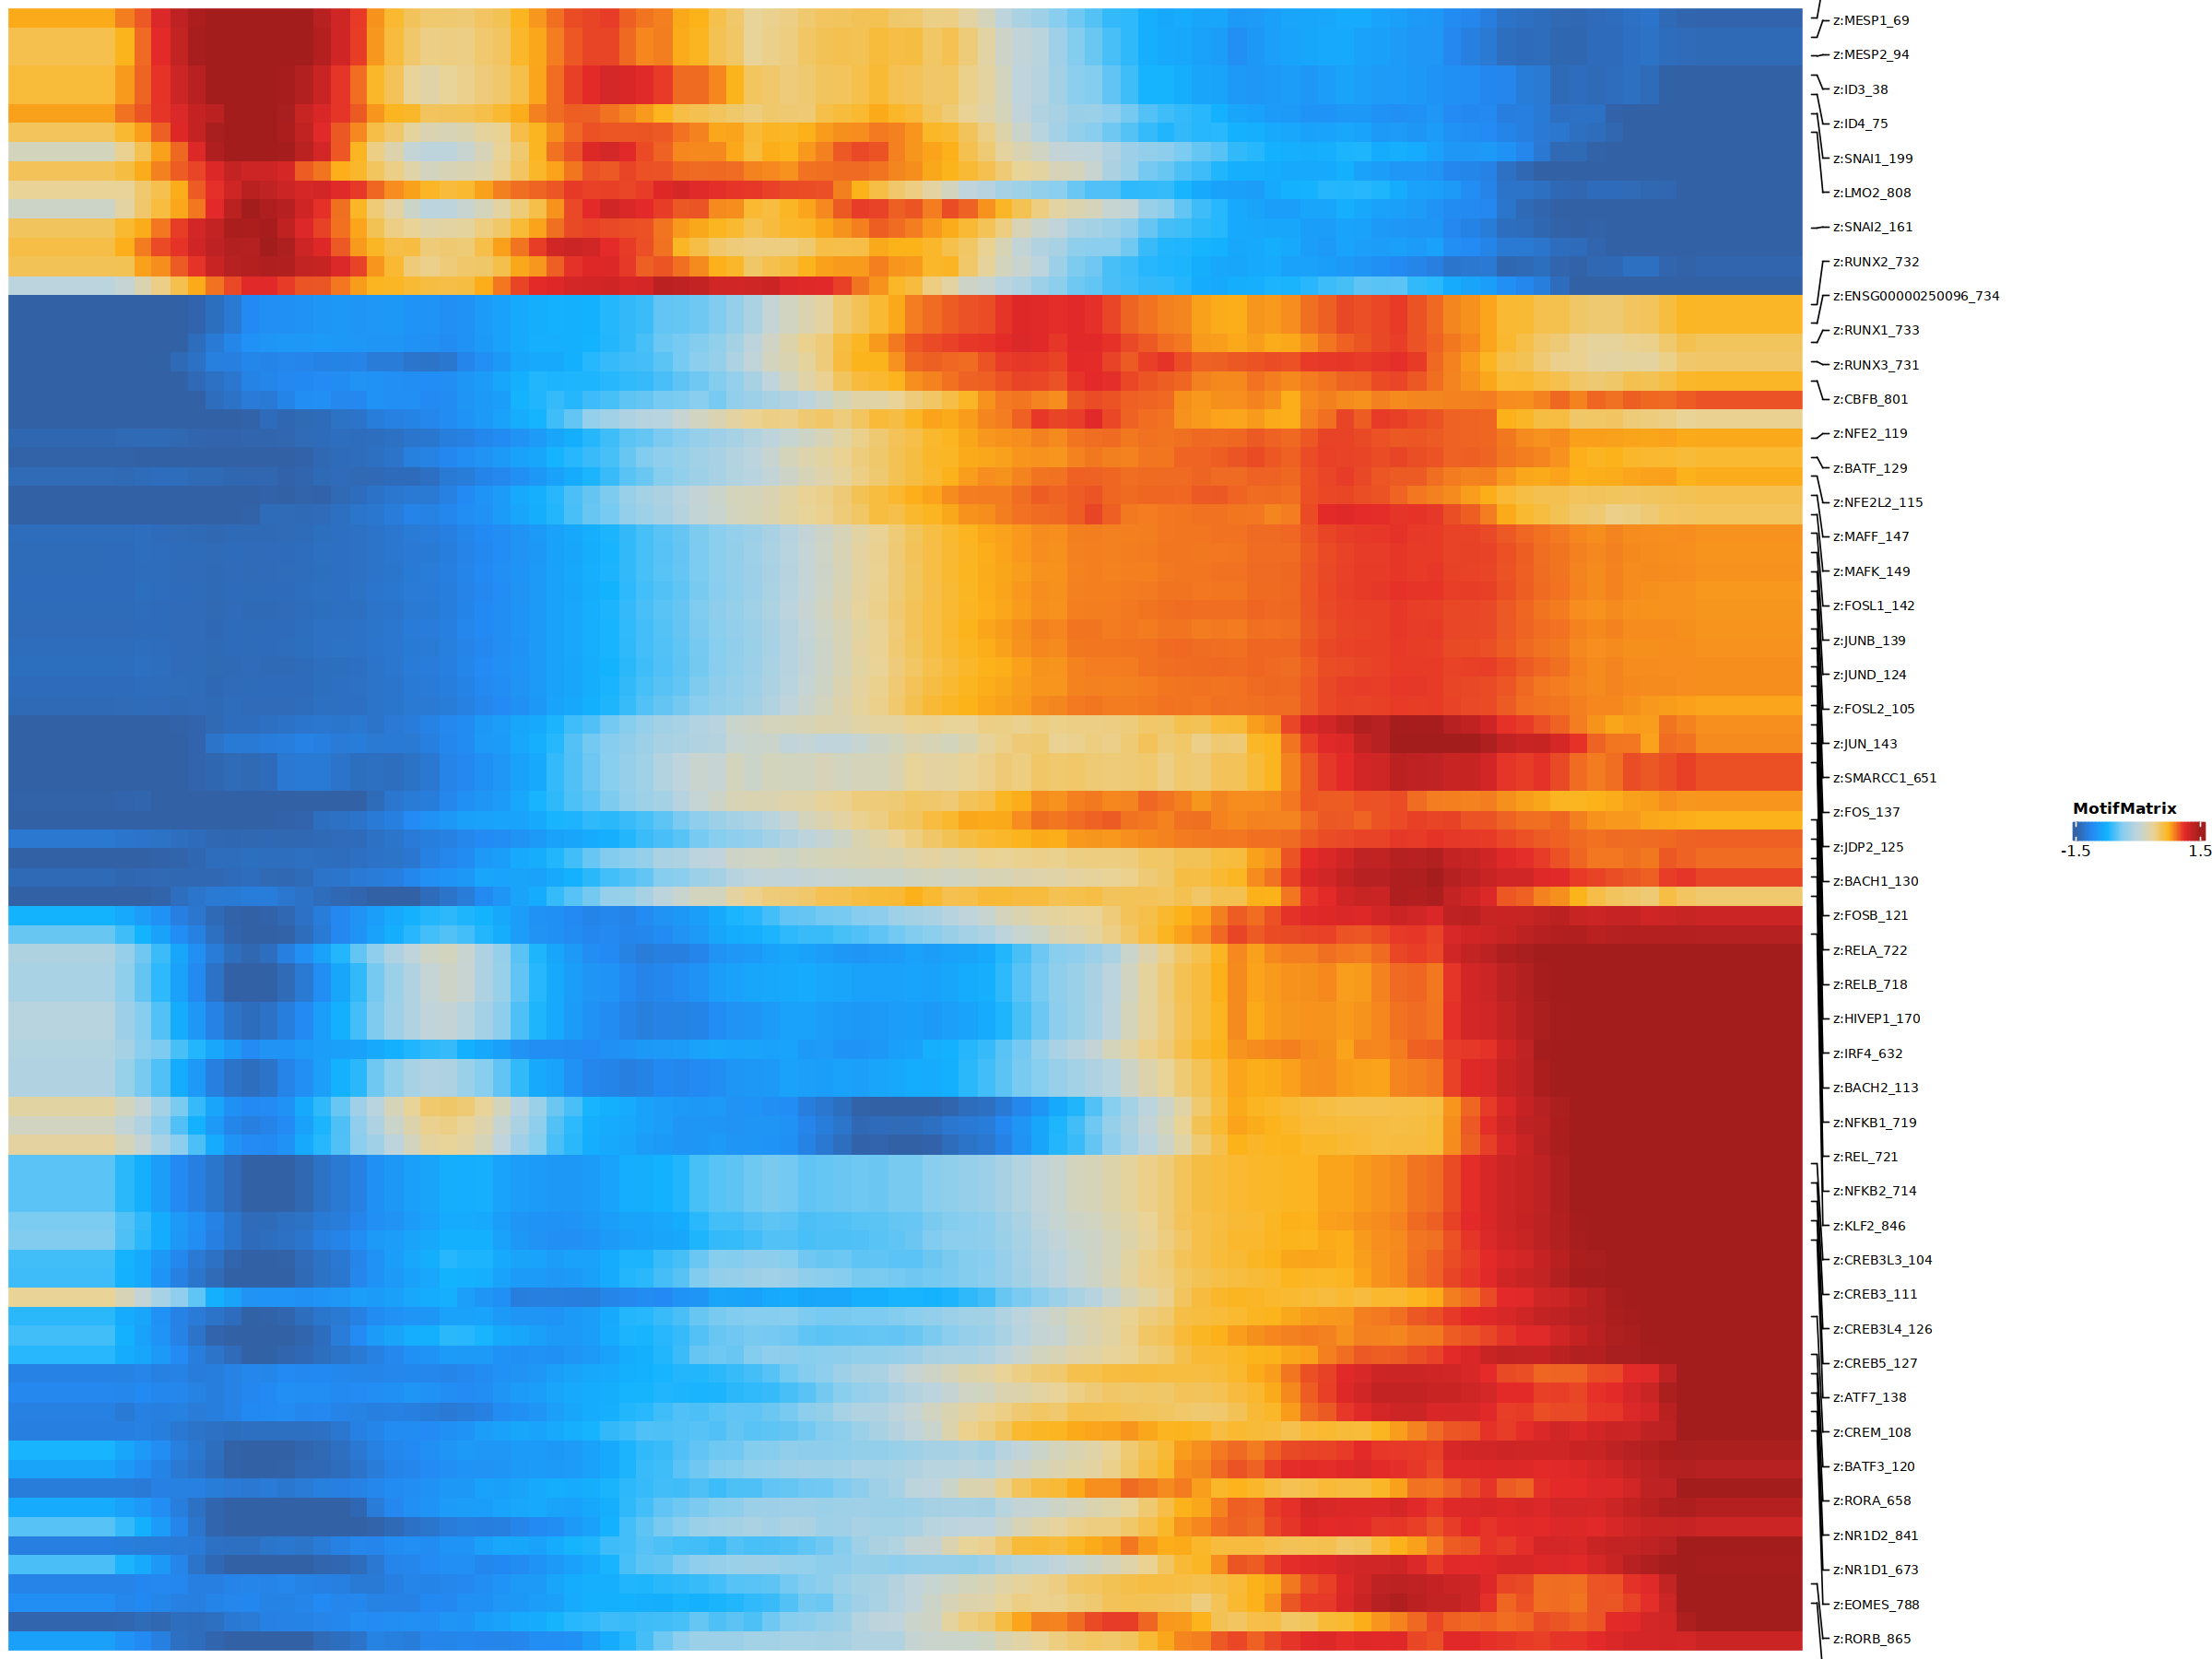

In [ ]:
p1


In [ ]:
rownames(trajMM) %>% str_subset("STAT")


[1] "deviations:STAT1_773"  "deviations:STAT5A_774" "deviations:STAT4_775" 
 [4] "deviations:STAT6_776"  "deviations:STAT3_777"  "deviations:STAT2_778" 
 [7] "deviations:STAT5B_779" "z:STAT1_773"           "z:STAT5A_774"         
[10] "z:STAT4_775"           "z:STAT6_776"           "z:STAT3_777"          
[13] "z:STAT2_778"           "z:STAT5B_779"

In [ ]:
p1[str_detect(rownames(p1), "BCL6|MAF|STAT"), ]


,T.0_1,T.1_2,T.2_3,T.3_4,T.4_5,T.5_6,T.6_7,T.7_8,T.8_9,T.9_10,⋯,T.90_91,T.91_92,T.92_93,T.93_94,T.94_95,T.95_96,T.96_97,T.97_98,T.98_99,T.99_100
z:MAFF_147,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.5,⋯,0.5329500,0.5481578,0.5537720,0.5710688,0.5888280,0.5888280,0.5888280,0.5888280,0.5888280,0.5888280
z:MAFK_149,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.500000,-1.5,⋯,0.4334197,0.4786323,0.5292451,0.5327744,0.5525056,0.5525056,0.5525056,0.5525056,0.5525056,0.5525056
z:MAFG_148,-1.480035,-1.480035,-1.480035,-1.480035,-1.480035,-1.480035,-1.461836,-1.453185,-1.496628,-1.5,⋯,0.7965705,0.8119569,0.8459295,0.8242742,0.8283543,0.8283543,0.8283543,0.8283543,0.8283543,0.8283543


Creating Trajectory Group Matrix..

Smoothing...

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe706e5ad-Date-2024-07-24_Time-20-43-59.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe706e5ad-Date-2024-07-24_Time-20-43-59.log



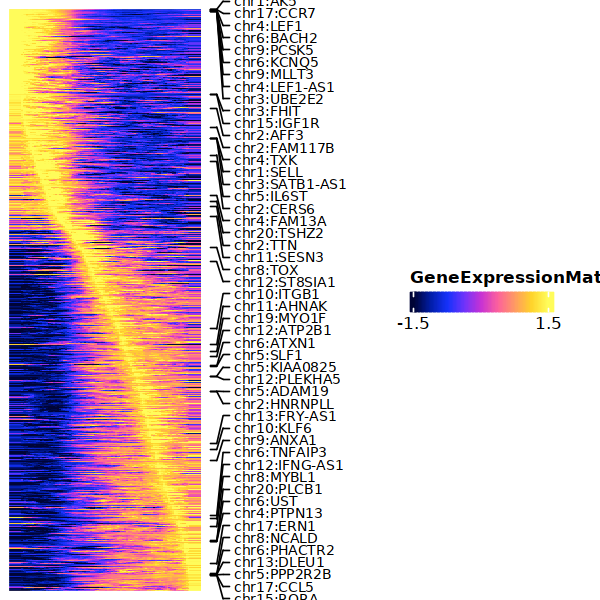

In [ ]:
# plot the trajectory in gene expression
trajGSE <- getTrajectory(
    ArchRProj = cd4t_atac, name = "CD4TnaC2toC1",
    useMatrix = "GeneExpressionMatrix", log2Norm = TRUE
)
p2 <- plotTrajectoryHeatmap(trajGSE, pal = paletteContinuous(set = "horizonExtra"))
p2


In [ ]:
# plot the trajectory in gene expression
trajGSE <- getTrajectory(
    ArchRProj = cd4t_atac, name = "CD4TnaC2toC1",
    useMatrix = "GeneScoreMatrix", log2Norm = TRUE
)


Creating Trajectory Group Matrix..

Smoothing...



ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe24424e5-Date-2024-07-24_Time-20-48-57.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-9fe24424e5-Date-2024-07-24_Time-20-48-57.log



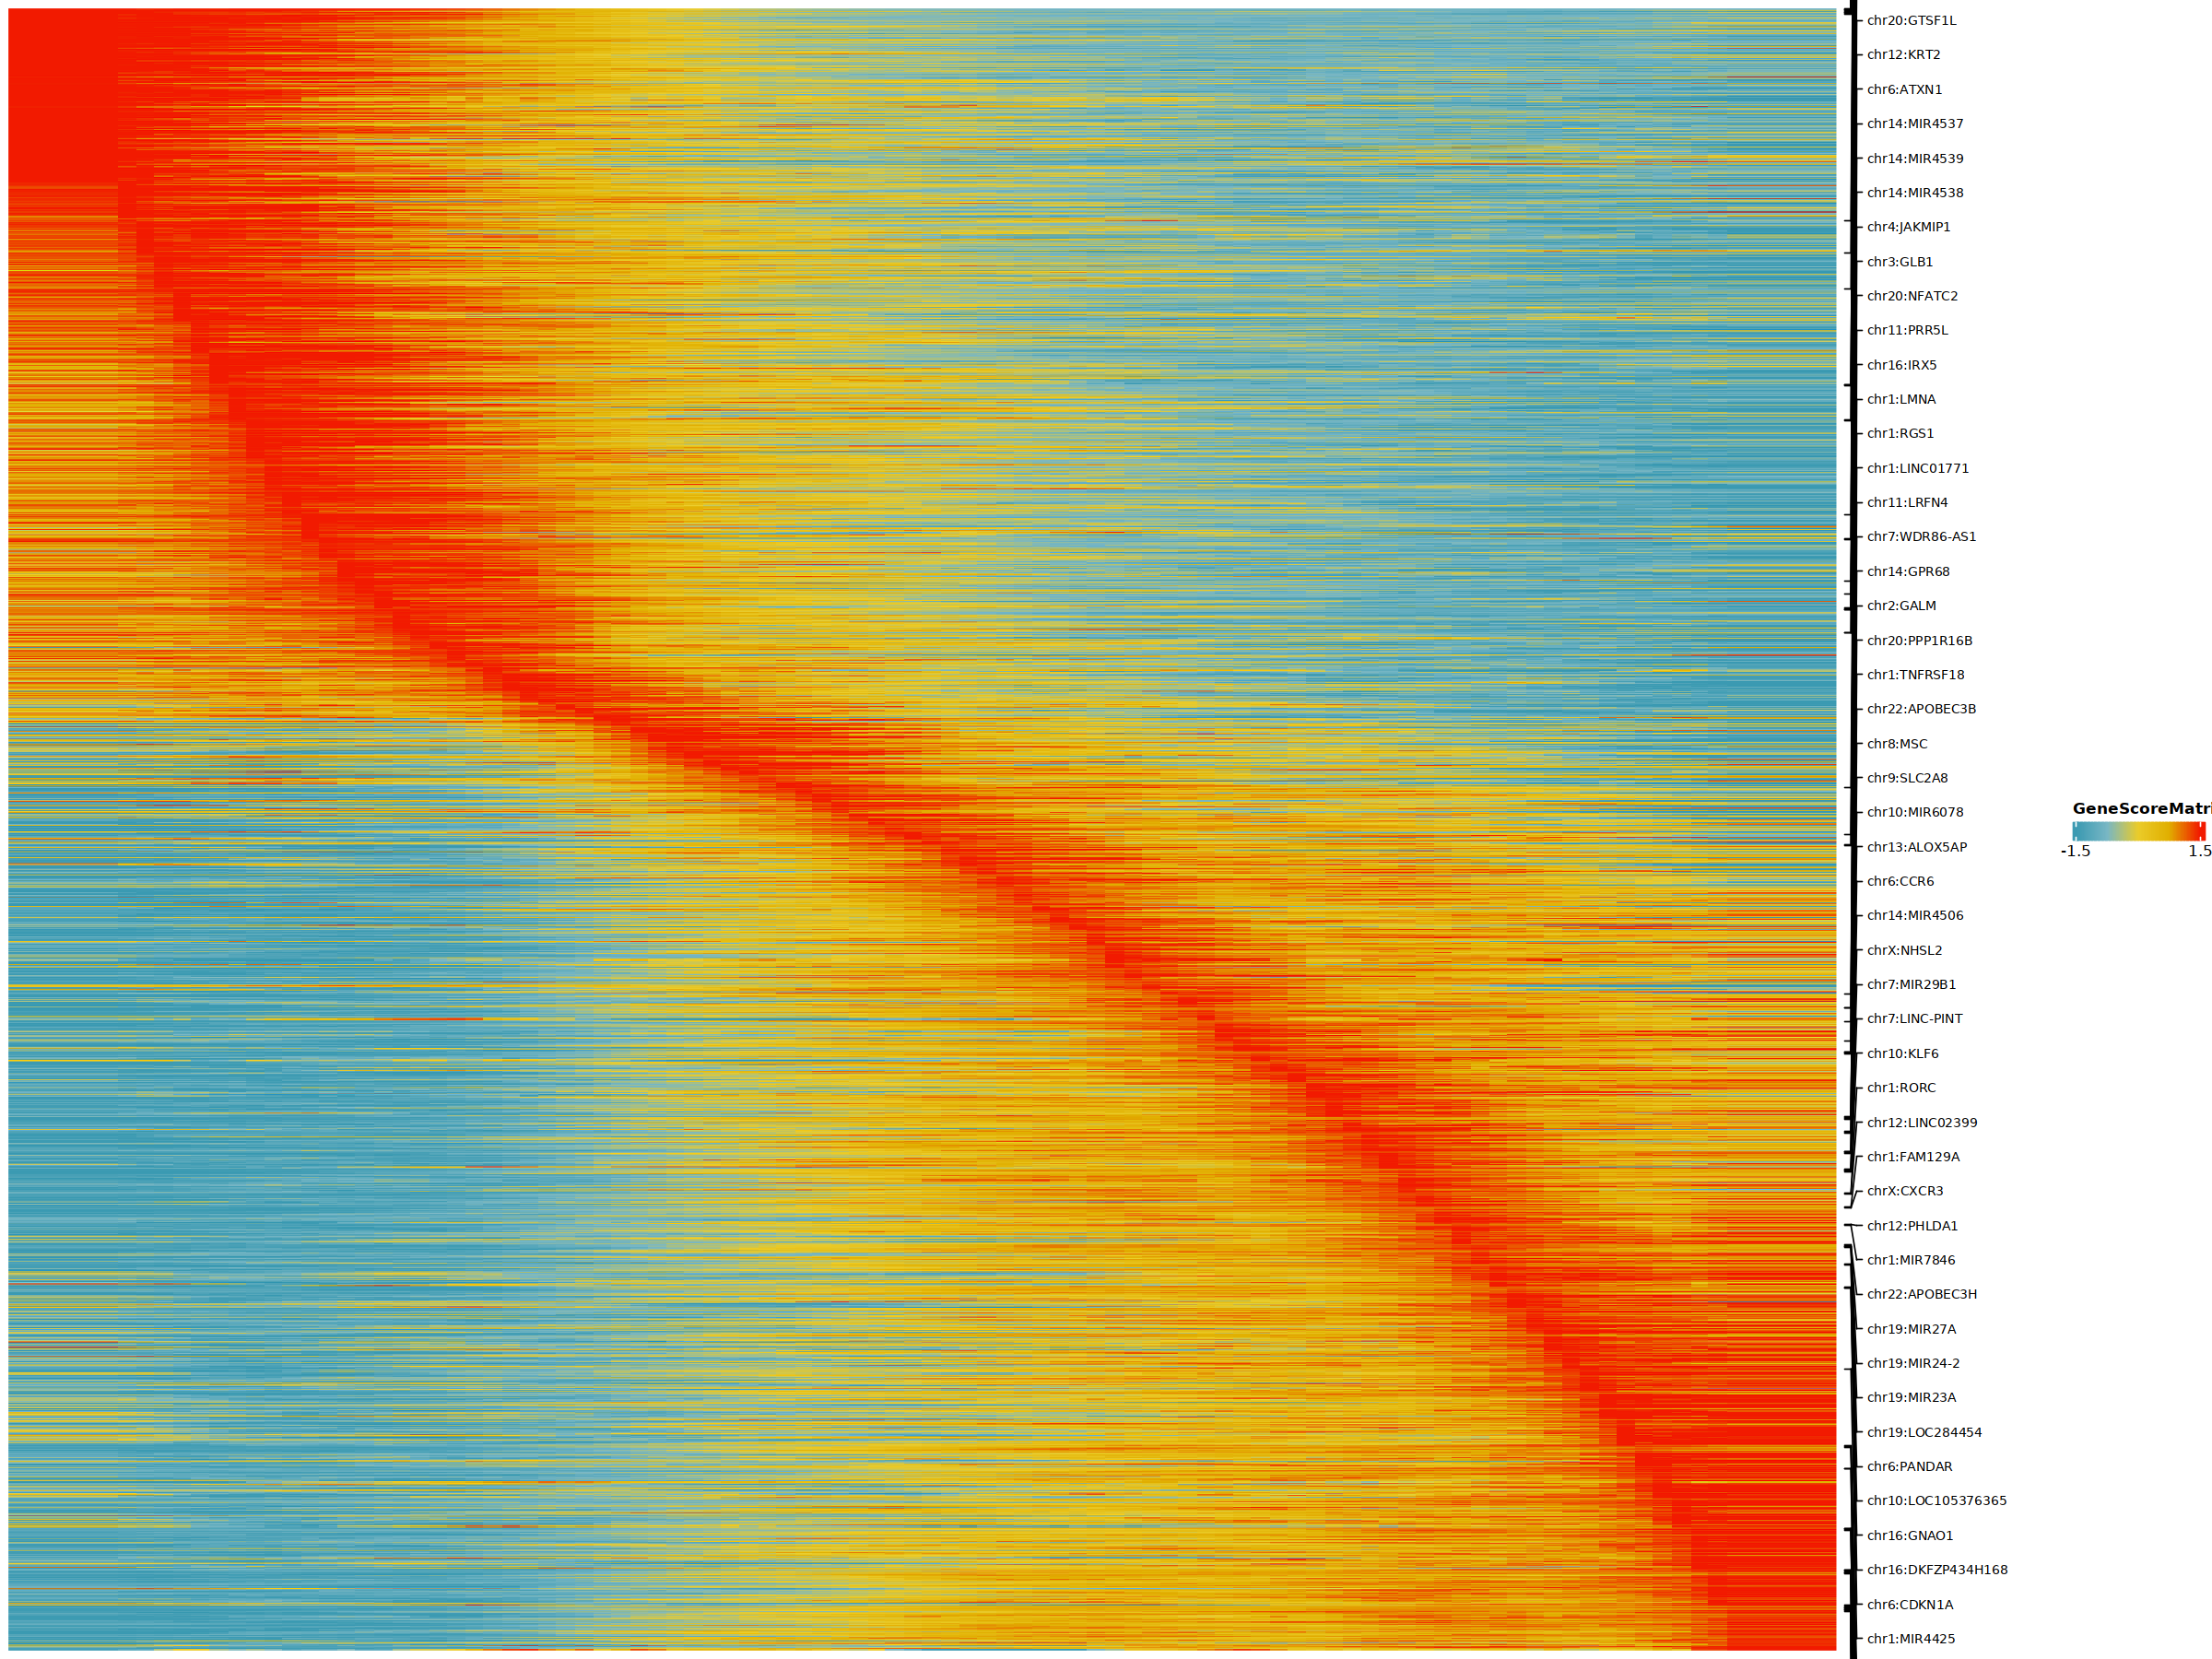

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 15)
p3 <- plotTrajectoryHeatmap(trajGSE,
    labelTop = 100,
    pal = paletteContinuous(set = "zissou")
)
p3
